# Eksperimen Q-Learning Scenario C

State: `(current_node, previous_node, progress_bin)` — agen juga mengetahui arah kedatangan.

Notebook ini tidak menduplikasi implementasi. Semua konfigurasi, download/load OSM, environment, reward, Q-Learning, metrik, grafik, dan peta berasal dari `rute_lari_core.py`.

In [ ]:
%pip install -q "osmnx>=2.0" networkx numpy pandas geopandas shapely folium matplotlib pyproj

## 1. Muat graf dengan core bersama

Jika GraphML belum ada, fungsi berikut mengunduh data OSM dengan konfigurasi yang sama seperti notebook analisis. Jika sudah ada, GraphML dimuat tanpa mengunduh ulang.

In [61]:
import importlib
import rute_lari_core

# Memuat ulang core agar perubahan grafik terbaru terbaca tanpa restart kernel.
importlib.reload(rute_lari_core)

from rute_lari_core import (
    load_or_download_graph,
    run_scenario_experiment,
    EPISODES,
    SEEDS,
)

G, START_NODE, GRAPH_PATH, downloaded_now = load_or_download_graph()

print(f'Graf: {G.number_of_nodes():,} node, {G.number_of_edges():,} edge')
print(f'Node start: {START_NODE}')
print(f'GraphML: {GRAPH_PATH}')
print('Sumber graf:', 'download baru' if downloaded_now else 'GraphML yang sudah ada')
print(f'Training: {len(SEEDS)} seed × {EPISODES:,} episode')

Graf: 8,027 node, 21,374 edge
Node start: 1720975931
GraphML: /Users/davidprastiyaimannuel/widya_kartika/david-31123022-tugas-akhir/data_osm_5km/graf_jalan_kaki_5km.graphml
Sumber graf: GraphML yang sudah ada
Training: 5 seed × 10,000 episode


## 2. Eksperimen pendahuluan: epsilon decay dinamis

Pada Scenario C, epsilon turun dari 1,00 ke 0,05 selama seluruh jumlah episode training. Karena lama fase eksplorasi ikut berubah, kelompok ini hanya digunakan untuk menunjukkan pengaruh jadwal epsilon relatif terhadap total episode; bukan pembandingan durasi training final.

Setiap titik melatih ulang lima seed dari awal dengan graf, reward, penyaringan ruas legal, state, dan evaluasi greedy yang sama. Total beban kelompok ini adalah 5 seed × (30.000 + 40.000 + 50.000 + 75.000) = 975.000 episode.


### 2.1 Training 30.000 episode


Menjalankan Scenario C: 5 seed x 30,000 episode
Jadwal epsilon: dinamis mengikuti total episode eksperimen
seed=0: over_distance, 5.57 km, is_loop=False
seed=1: over_distance, 5.57 km, is_loop=False
seed=2: over_distance, 5.58 km, is_loop=False
seed=3: success, 5.15 km, is_loop=True
seed=4: no_available_action, 5.17 km, is_loop=False
Tampilan vertikal metrik evaluasi utama per seed


seed,0,1,2,3,4
is_loop,False,False,False,True,False
total_distance_m,5568.150949,5571.042654,5582.18639,5153.544144,5172.220877
absolute_distance_error_m,568.150949,571.042654,582.18639,153.544144,172.220877
total_reward,-71.996141,-55.771954,-64.258766,93.635829,-41.878001
mean_comfort,0.714373,0.676306,0.68693,0.703924,0.691092
return_progress_ratio,0.478261,0.55,0.589744,0.777778,0.625
distance_to_start_at_end_m,1174.595837,729.691832,981.63156,0.0,516.192793
closing_action_available,False,False,False,True,False
termination_reason,over_distance,over_distance,over_distance,success,no_available_action


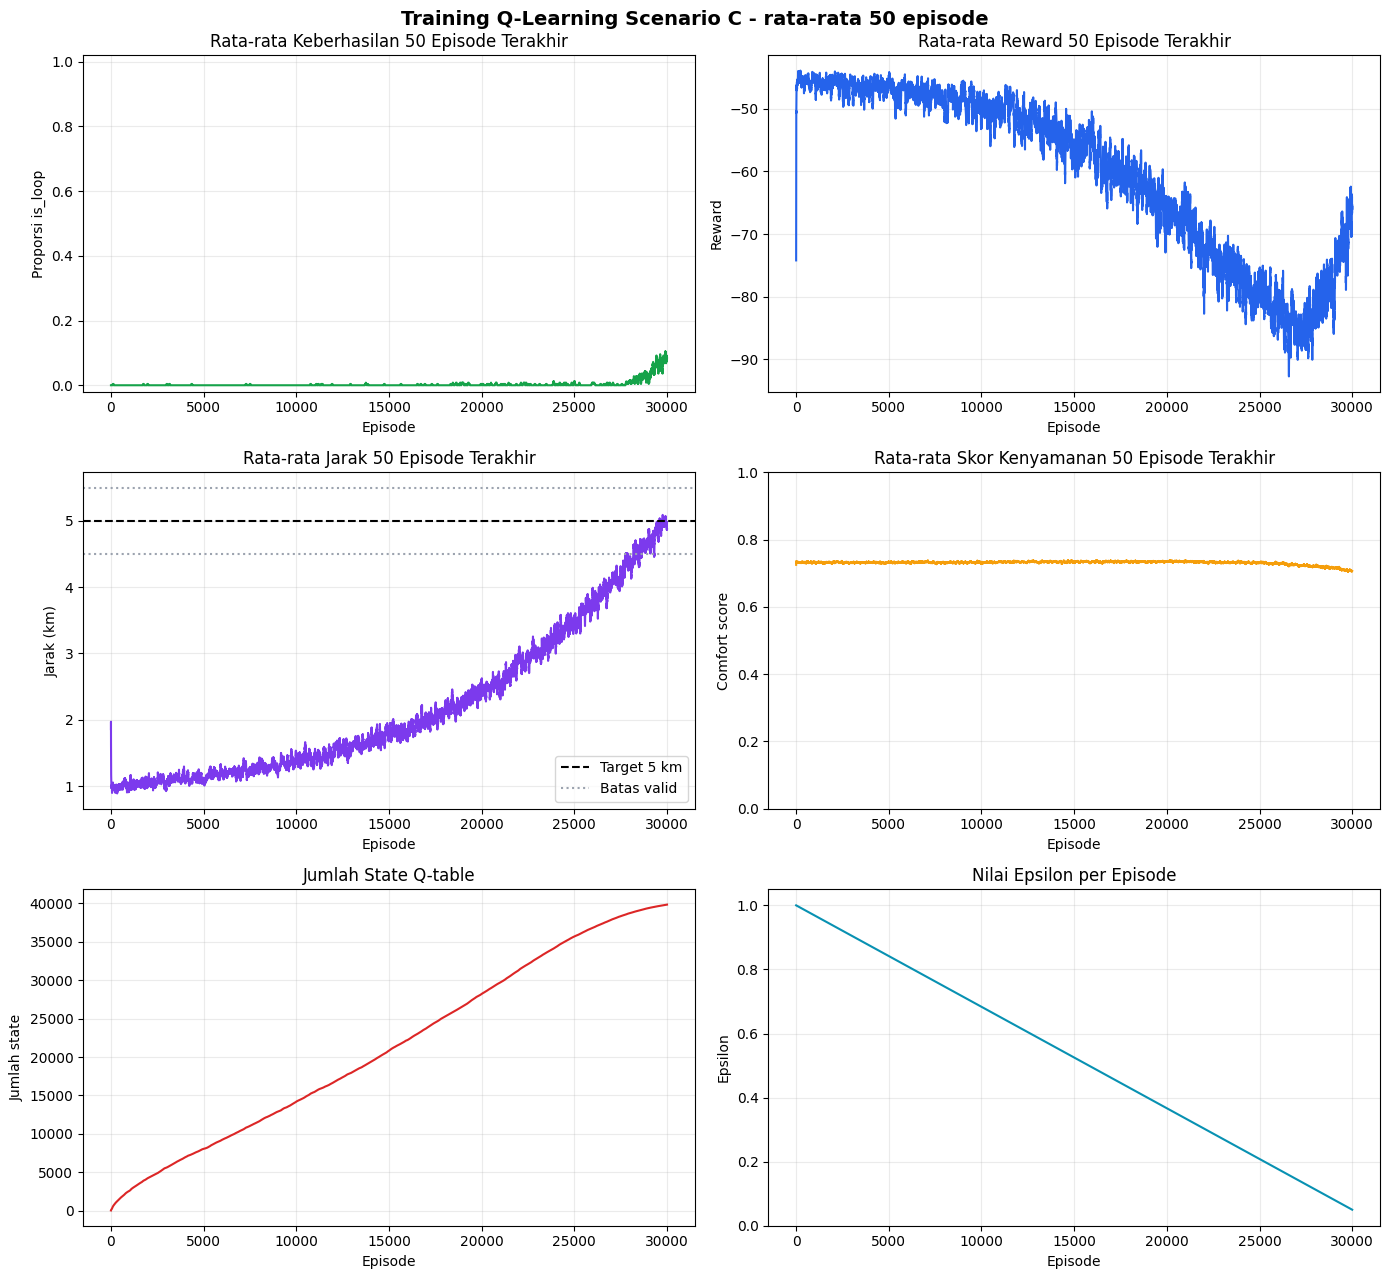

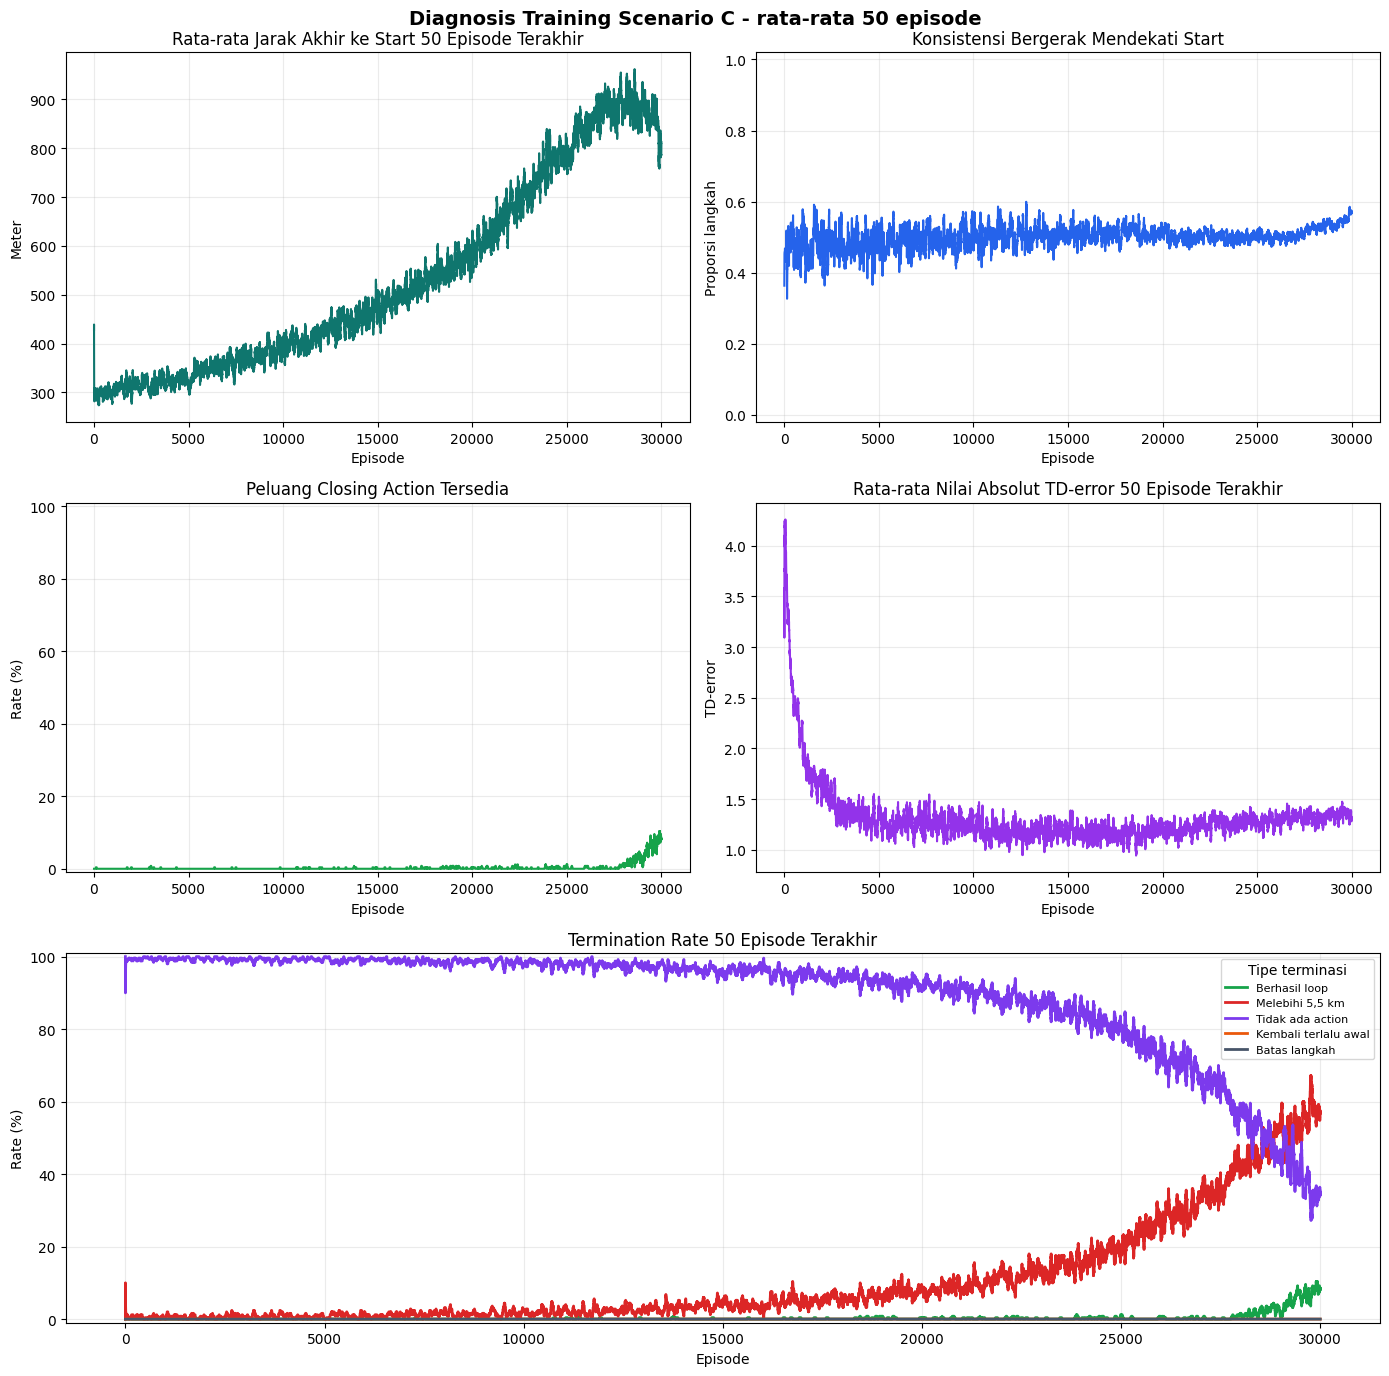

=== Q-TABLE / SEED YANG DIPILIH UNTUK PETA ===
Scenario: C; seed: 3
Metrik: is_loop=True, jarak=5153.54 m, galat=153.54 m, comfort=0.704, return_progress=0.778, jarak akhir ke start=0.00 m, terminasi=success
Alasan: Dipilih dari 1 loop valid: galat jarak paling kecil; jika setara, comfort lalu return progress lebih tinggi.


History: /Users/davidprastiyaimannuel/widya_kartika/david-31123022-tugas-akhir/hasil_bab_4/training_qlearning_5km/sensitivitas_episode_30000_C/training_history_C.csv
Evaluasi: /Users/davidprastiyaimannuel/widya_kartika/david-31123022-tugas-akhir/hasil_bab_4/training_qlearning_5km/sensitivitas_episode_30000_C/evaluation_metrics_C.csv
Diagnosis: /Users/davidprastiyaimannuel/widya_kartika/david-31123022-tugas-akhir/hasil_bab_4/training_qlearning_5km/sensitivitas_episode_30000_C/diagnosis_metrics_C.csv
Termination rate training: /Users/davidprastiyaimannuel/widya_kartika/david-31123022-tugas-akhir/hasil_bab_4/training_qlearning_5km/sensitivitas_episode_30000_C/termination_rates_training_C.csv
Termination rate evaluasi: /Users/davidprastiyaimannuel/widya_kartika/david-31123022-tugas-akhir/hasil_bab_4/training_qlearning_5km/sensitivitas_episode_30000_C/termination_rates_evaluation_C.csv
Grafik training utama: /Users/davidprastiyaimannuel/widya_kartika/david-31123022-tugas-akhir/hasil_bab_4/t

In [62]:
import importlib
# Memuat ulang core agar notebook memakai fungsi dan parameter terbaru.
importlib.reload(rute_lari_core)

result_c_30000 = rute_lari_core.run_scenario_experiment(
    G, START_NODE, 'C',
    episodes=30_000,
    result_subdir='sensitivitas_episode_30000_C',
)


### 2.2 Training 40.000 episode


Menjalankan Scenario C: 5 seed x 40,000 episode
Jadwal epsilon: dinamis mengikuti total episode eksperimen
seed=0: over_distance, 5.50 km, is_loop=False
seed=1: over_distance, 5.52 km, is_loop=False
seed=2: success, 5.12 km, is_loop=True
seed=3: success, 5.12 km, is_loop=True
seed=4: over_distance, 5.51 km, is_loop=False
Tampilan vertikal metrik evaluasi utama per seed


seed,0,1,2,3,4
is_loop,False,False,True,True,False
total_distance_m,5500.262601,5523.560172,5118.292792,5118.292792,5512.053834
absolute_distance_error_m,500.262601,523.560172,118.292792,118.292792,512.053834
total_reward,-62.473086,-48.453962,94.566086,94.566086,-48.512886
mean_comfort,0.680211,0.707787,0.704004,0.704004,0.714023
return_progress_ratio,0.710526,0.410256,0.861111,0.861111,0.44186
distance_to_start_at_end_m,660.19017,1146.915423,0.0,0.0,1127.286639
closing_action_available,False,False,True,True,False
termination_reason,over_distance,over_distance,success,success,over_distance


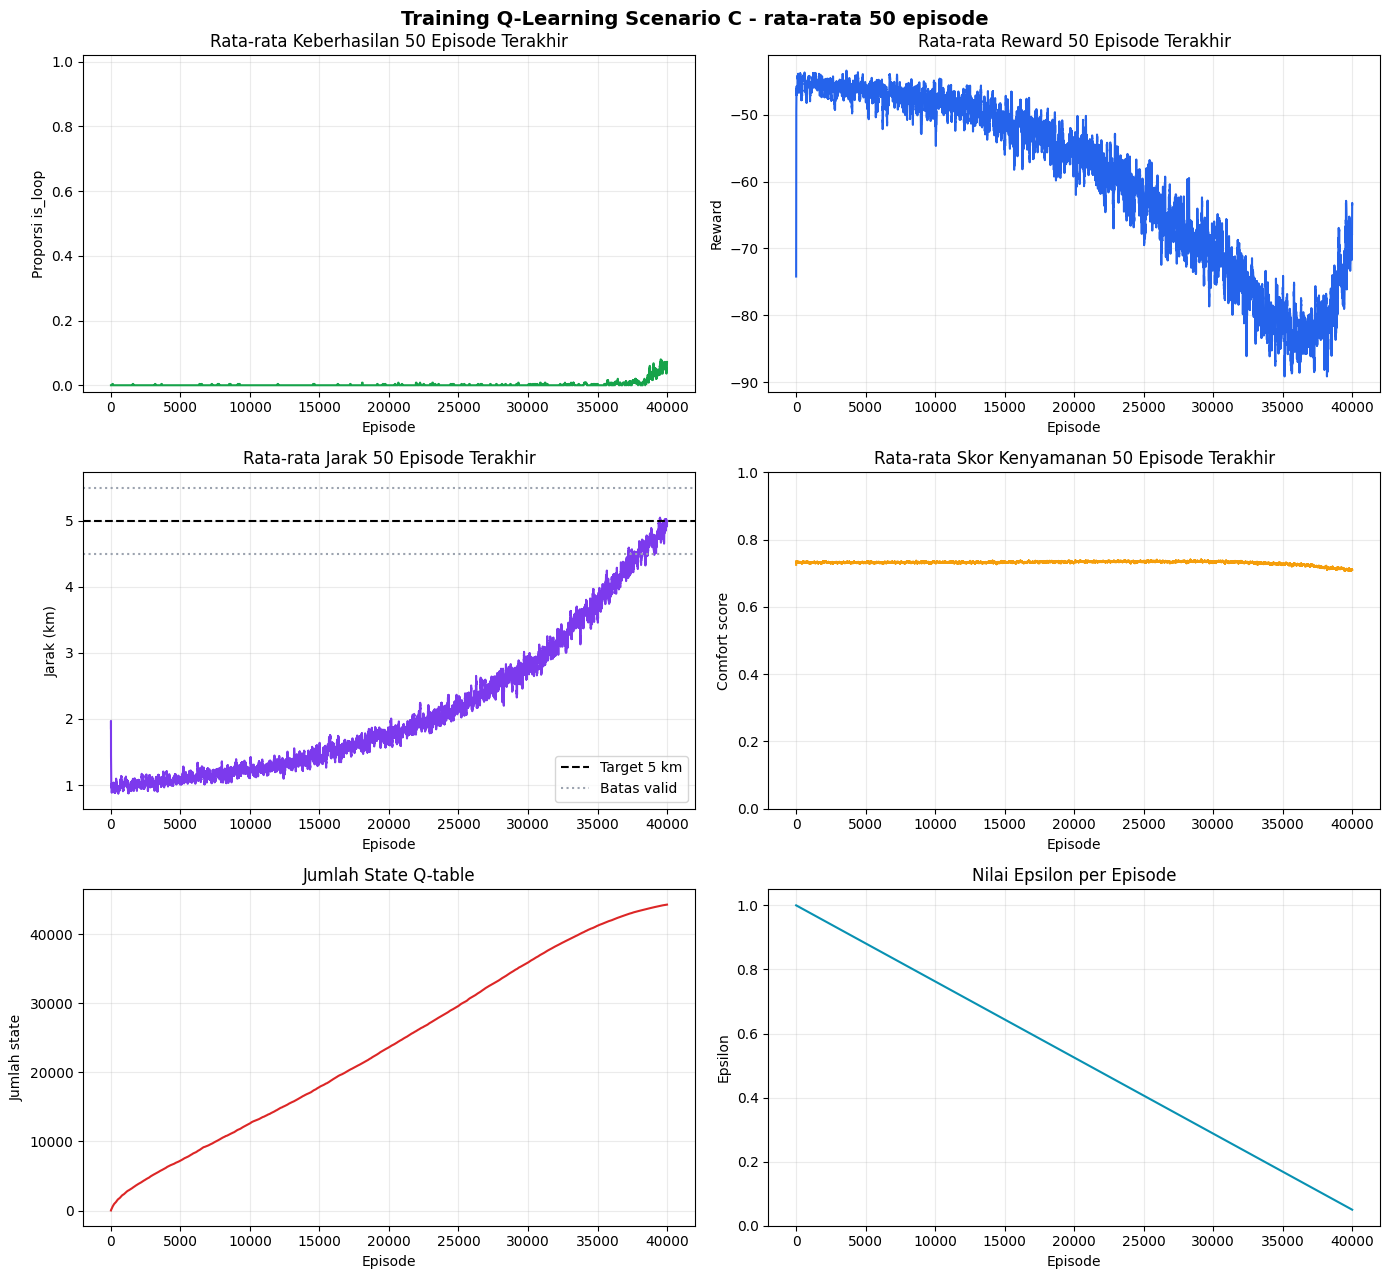

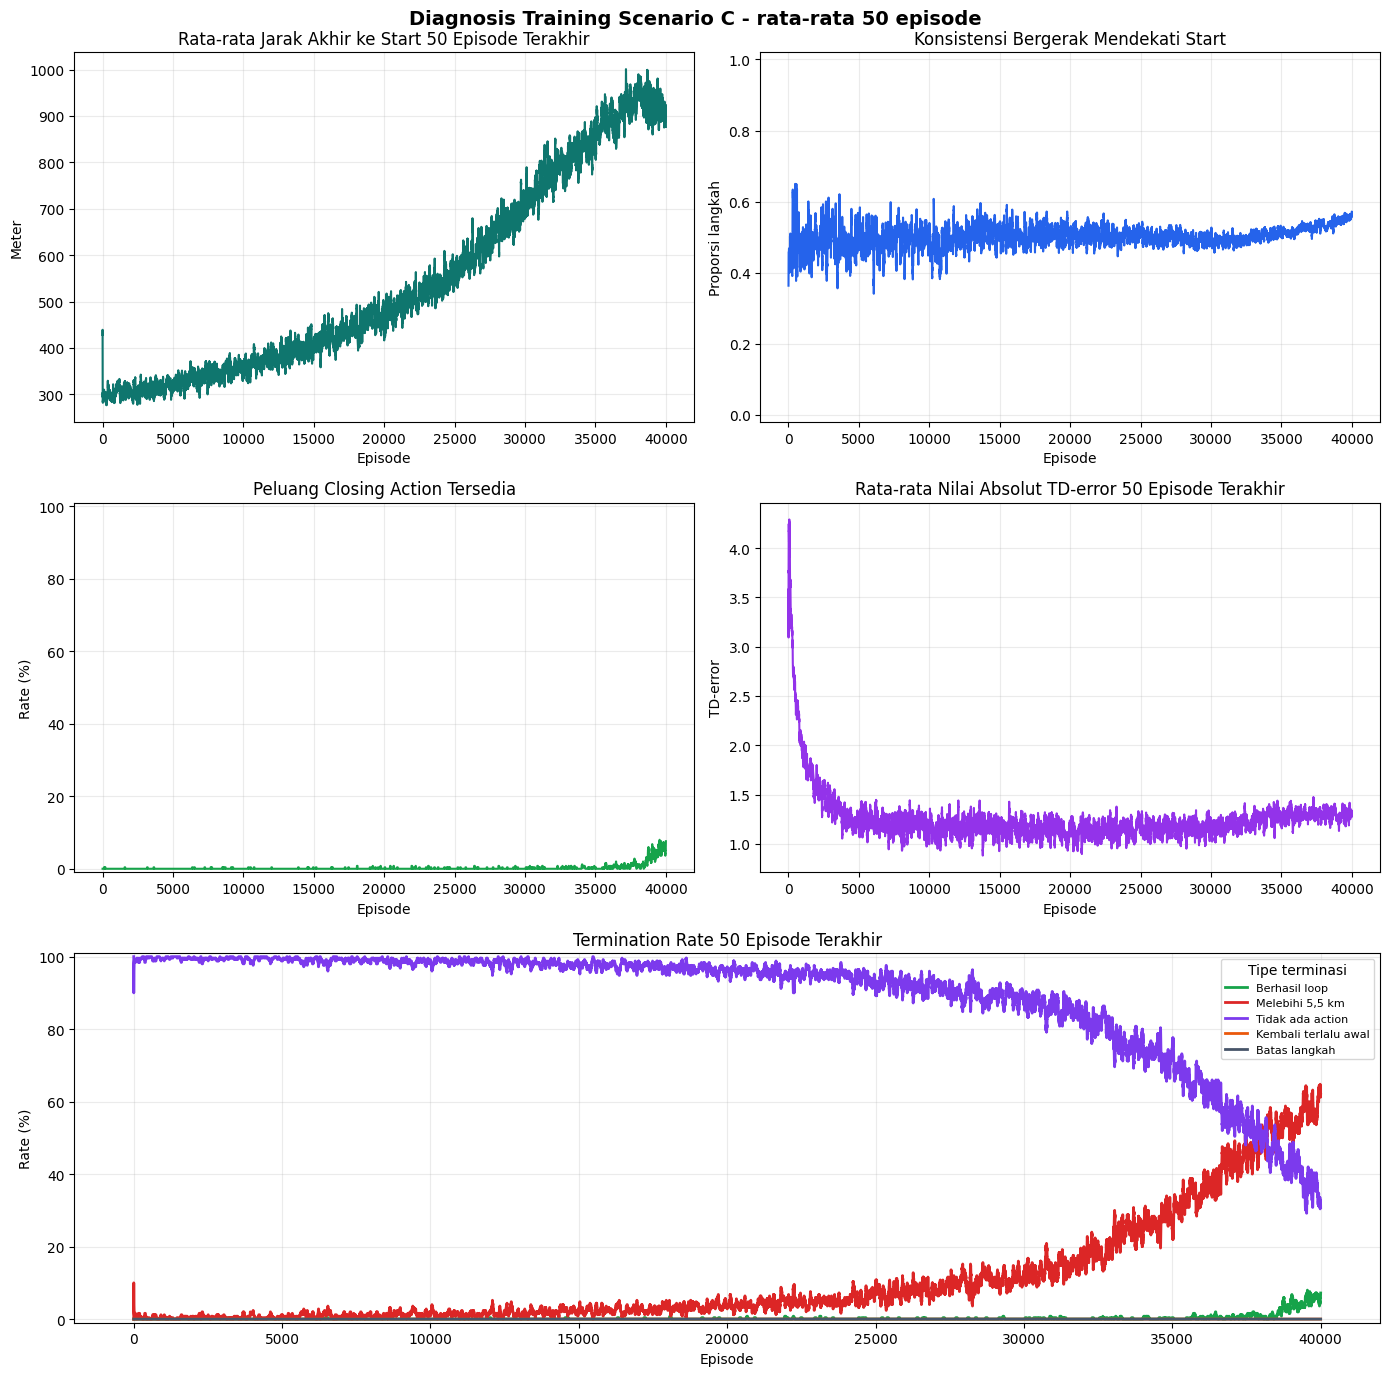

=== Q-TABLE / SEED YANG DIPILIH UNTUK PETA ===
Scenario: C; seed: 2
Metrik: is_loop=True, jarak=5118.29 m, galat=118.29 m, comfort=0.704, return_progress=0.861, jarak akhir ke start=0.00 m, terminasi=success
Alasan: Dipilih dari 2 loop valid: galat jarak paling kecil; jika setara, comfort lalu return progress lebih tinggi.


History: /Users/davidprastiyaimannuel/widya_kartika/david-31123022-tugas-akhir/hasil_bab_4/training_qlearning_5km/sensitivitas_episode_40000_C/training_history_C.csv
Evaluasi: /Users/davidprastiyaimannuel/widya_kartika/david-31123022-tugas-akhir/hasil_bab_4/training_qlearning_5km/sensitivitas_episode_40000_C/evaluation_metrics_C.csv
Diagnosis: /Users/davidprastiyaimannuel/widya_kartika/david-31123022-tugas-akhir/hasil_bab_4/training_qlearning_5km/sensitivitas_episode_40000_C/diagnosis_metrics_C.csv
Termination rate training: /Users/davidprastiyaimannuel/widya_kartika/david-31123022-tugas-akhir/hasil_bab_4/training_qlearning_5km/sensitivitas_episode_40000_C/termination_rates_training_C.csv
Termination rate evaluasi: /Users/davidprastiyaimannuel/widya_kartika/david-31123022-tugas-akhir/hasil_bab_4/training_qlearning_5km/sensitivitas_episode_40000_C/termination_rates_evaluation_C.csv
Grafik training utama: /Users/davidprastiyaimannuel/widya_kartika/david-31123022-tugas-akhir/hasil_bab_4/t

In [63]:
import importlib
# Memuat ulang core agar notebook memakai fungsi dan parameter terbaru.
importlib.reload(rute_lari_core)

result_c_40000 = rute_lari_core.run_scenario_experiment(
    G, START_NODE, 'C',
    episodes=40_000,
    result_subdir='sensitivitas_episode_40000_C',
)


### 2.3 Training 50.000 episode


Menjalankan Scenario C: 5 seed x 50,000 episode
Jadwal epsilon: dinamis mengikuti total episode eksperimen
seed=0: success, 5.33 km, is_loop=True
seed=1: over_distance, 5.56 km, is_loop=False
seed=2: over_distance, 5.52 km, is_loop=False
seed=3: success, 4.82 km, is_loop=True
seed=4: over_distance, 5.52 km, is_loop=False
Tampilan vertikal metrik evaluasi utama per seed


seed,0,1,2,3,4
is_loop,True,False,False,True,False
total_distance_m,5325.293749,5563.763006,5522.265793,4817.120312,5517.331307
absolute_distance_error_m,325.293749,563.763006,522.265793,182.879688,517.331307
total_reward,94.972197,-40.888742,-73.045352,94.495602,-55.52484
mean_comfort,0.7037,0.714527,0.680621,0.70488,0.719132
return_progress_ratio,0.857143,0.355556,0.581395,0.868421,0.413043
distance_to_start_at_end_m,0.0,1344.104659,1368.309026,0.0,1041.37972
closing_action_available,True,False,False,True,False
termination_reason,success,over_distance,over_distance,success,over_distance


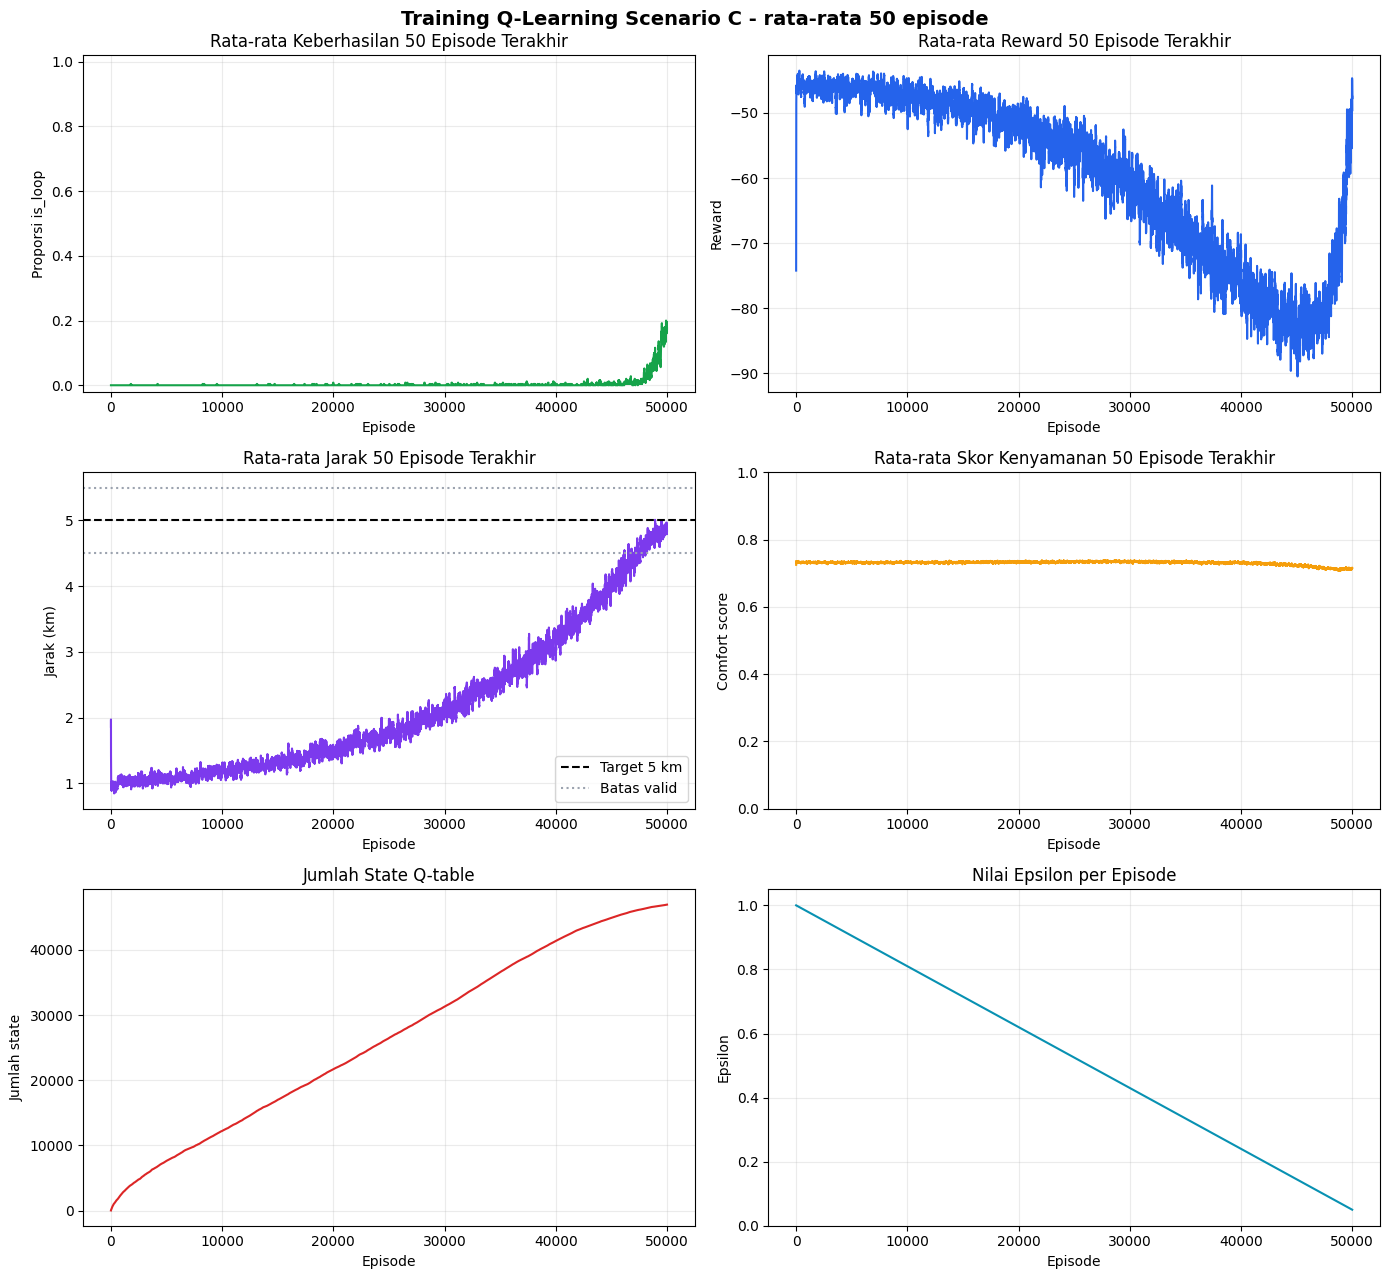

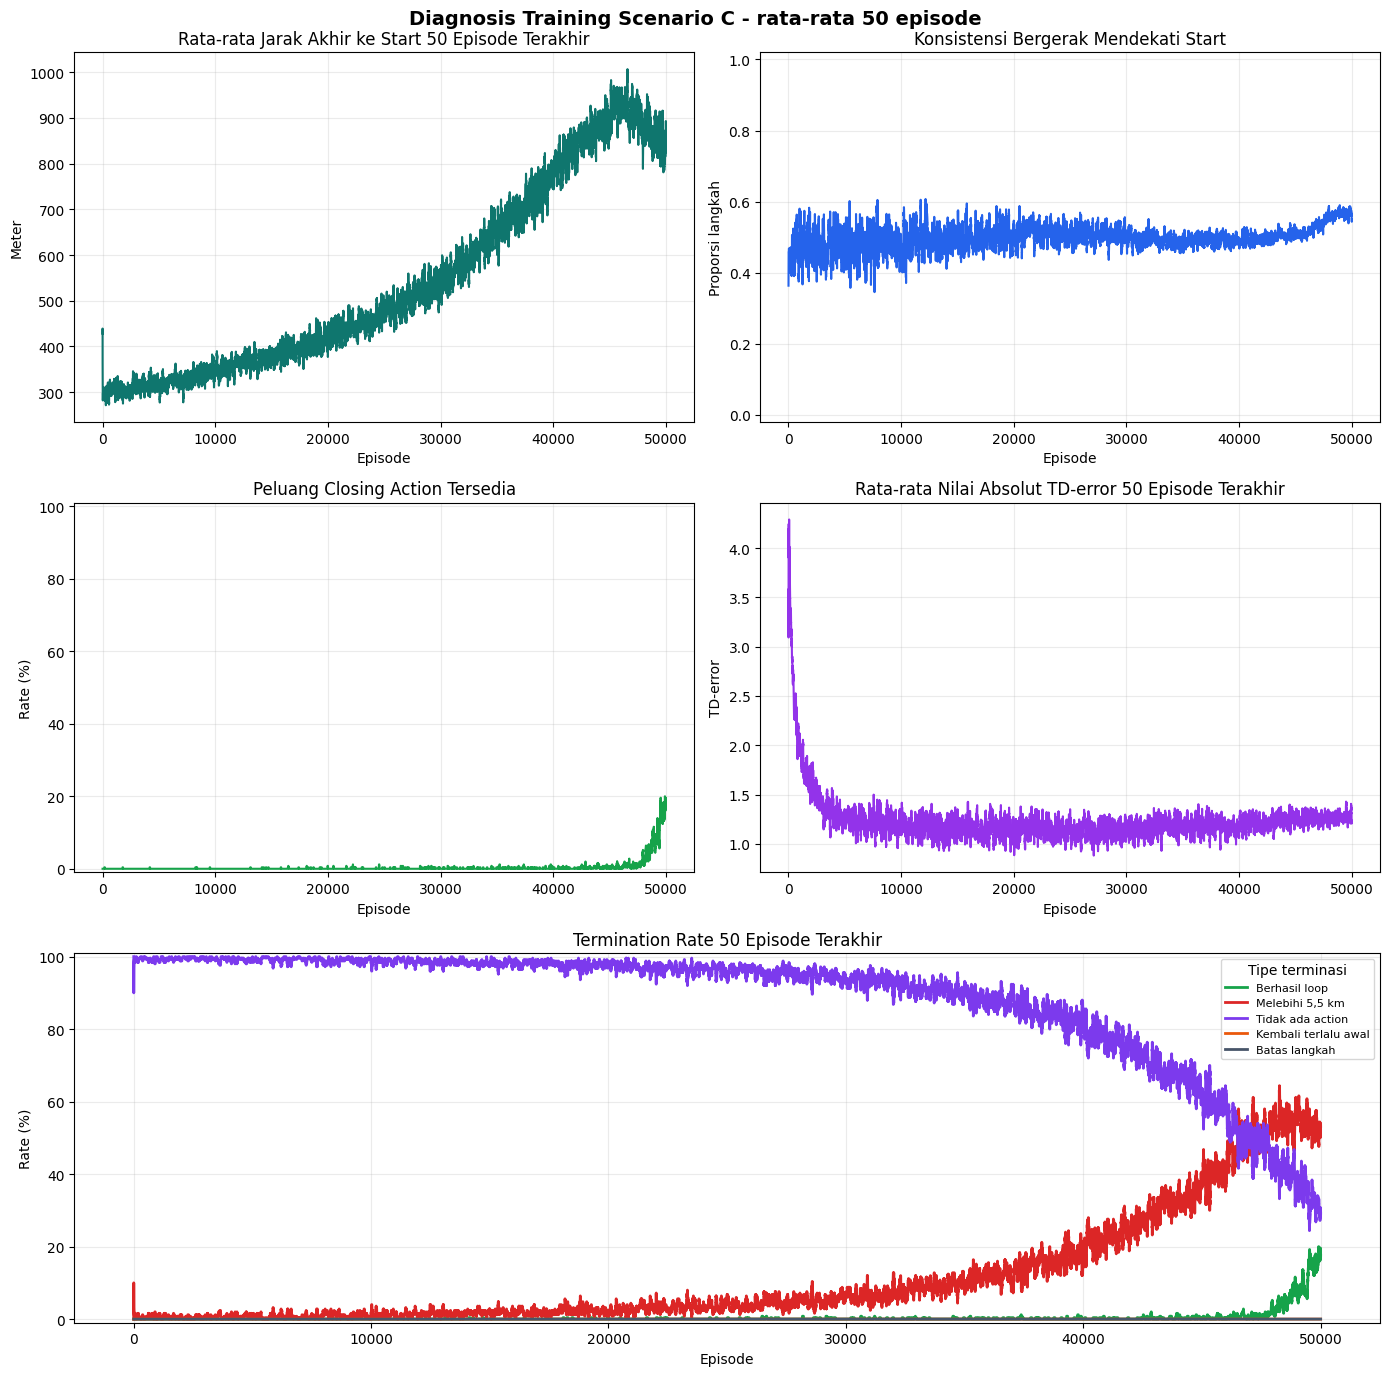

=== Q-TABLE / SEED YANG DIPILIH UNTUK PETA ===
Scenario: C; seed: 3
Metrik: is_loop=True, jarak=4817.12 m, galat=182.88 m, comfort=0.705, return_progress=0.868, jarak akhir ke start=0.00 m, terminasi=success
Alasan: Dipilih dari 2 loop valid: galat jarak paling kecil; jika setara, comfort lalu return progress lebih tinggi.


History: /Users/davidprastiyaimannuel/widya_kartika/david-31123022-tugas-akhir/hasil_bab_4/training_qlearning_5km/sensitivitas_episode_50000_C/training_history_C.csv
Evaluasi: /Users/davidprastiyaimannuel/widya_kartika/david-31123022-tugas-akhir/hasil_bab_4/training_qlearning_5km/sensitivitas_episode_50000_C/evaluation_metrics_C.csv
Diagnosis: /Users/davidprastiyaimannuel/widya_kartika/david-31123022-tugas-akhir/hasil_bab_4/training_qlearning_5km/sensitivitas_episode_50000_C/diagnosis_metrics_C.csv
Termination rate training: /Users/davidprastiyaimannuel/widya_kartika/david-31123022-tugas-akhir/hasil_bab_4/training_qlearning_5km/sensitivitas_episode_50000_C/termination_rates_training_C.csv
Termination rate evaluasi: /Users/davidprastiyaimannuel/widya_kartika/david-31123022-tugas-akhir/hasil_bab_4/training_qlearning_5km/sensitivitas_episode_50000_C/termination_rates_evaluation_C.csv
Grafik training utama: /Users/davidprastiyaimannuel/widya_kartika/david-31123022-tugas-akhir/hasil_bab_4/t

In [64]:
import importlib
# Memuat ulang core agar notebook memakai fungsi dan parameter terbaru.
importlib.reload(rute_lari_core)

result_c_50000 = rute_lari_core.run_scenario_experiment(
    G, START_NODE, 'C',
    episodes=50_000,
    result_subdir='sensitivitas_episode_50000_C',
)


### 2.4 Training 75.000 episode


Menjalankan Scenario C: 5 seed x 75,000 episode
Jadwal epsilon: dinamis mengikuti total episode eksperimen
seed=0: over_distance, 5.52 km, is_loop=False
seed=1: over_distance, 5.56 km, is_loop=False
seed=2: success, 4.98 km, is_loop=True
seed=3: success, 4.56 km, is_loop=True
seed=4: success, 5.15 km, is_loop=True
Tampilan vertikal metrik evaluasi utama per seed


seed,0,1,2,3,4
is_loop,False,False,True,True,True
total_distance_m,5517.500571,5562.125269,4978.809527,4557.974065,5154.131769
absolute_distance_error_m,517.500571,562.125269,21.190473,442.025935,154.131769
total_reward,-48.177465,-79.591484,86.423805,67.741335,81.714569
mean_comfort,0.715875,0.72062,0.705884,0.706434,0.771517
return_progress_ratio,0.44,0.404255,0.820513,0.777778,0.736842
distance_to_start_at_end_m,1167.114676,1158.472334,0.0,0.0,0.0
closing_action_available,False,False,True,True,True
termination_reason,over_distance,over_distance,success,success,success


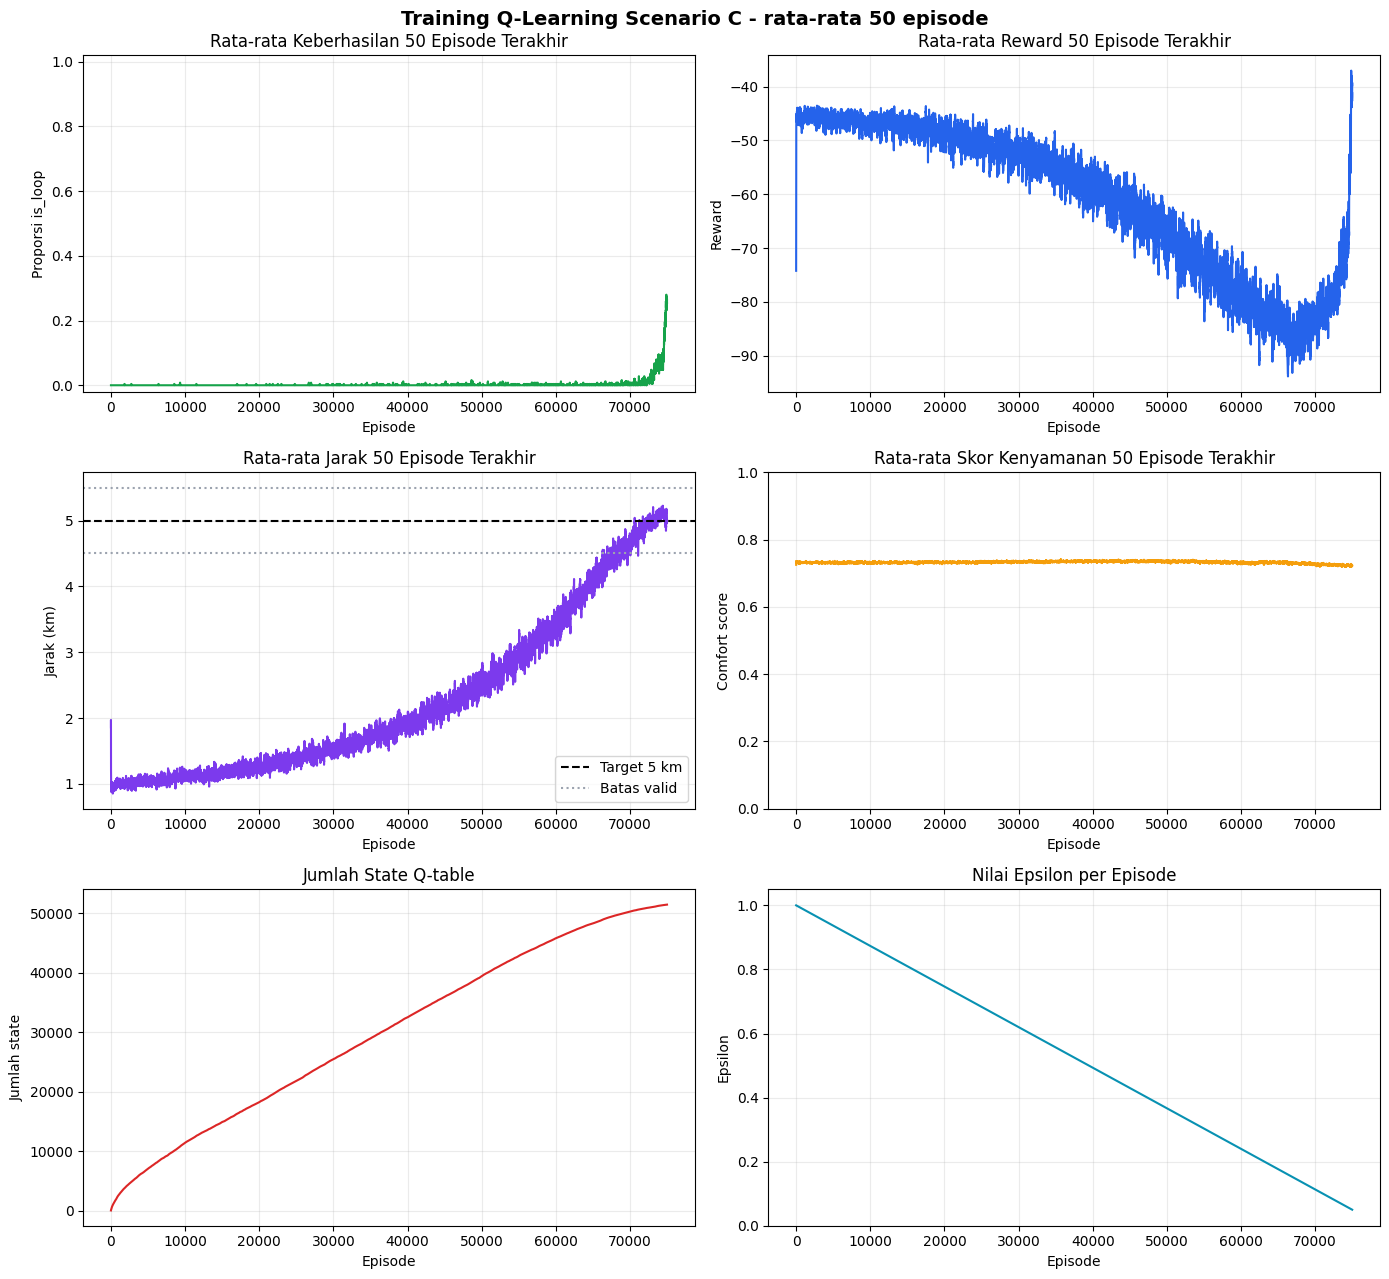

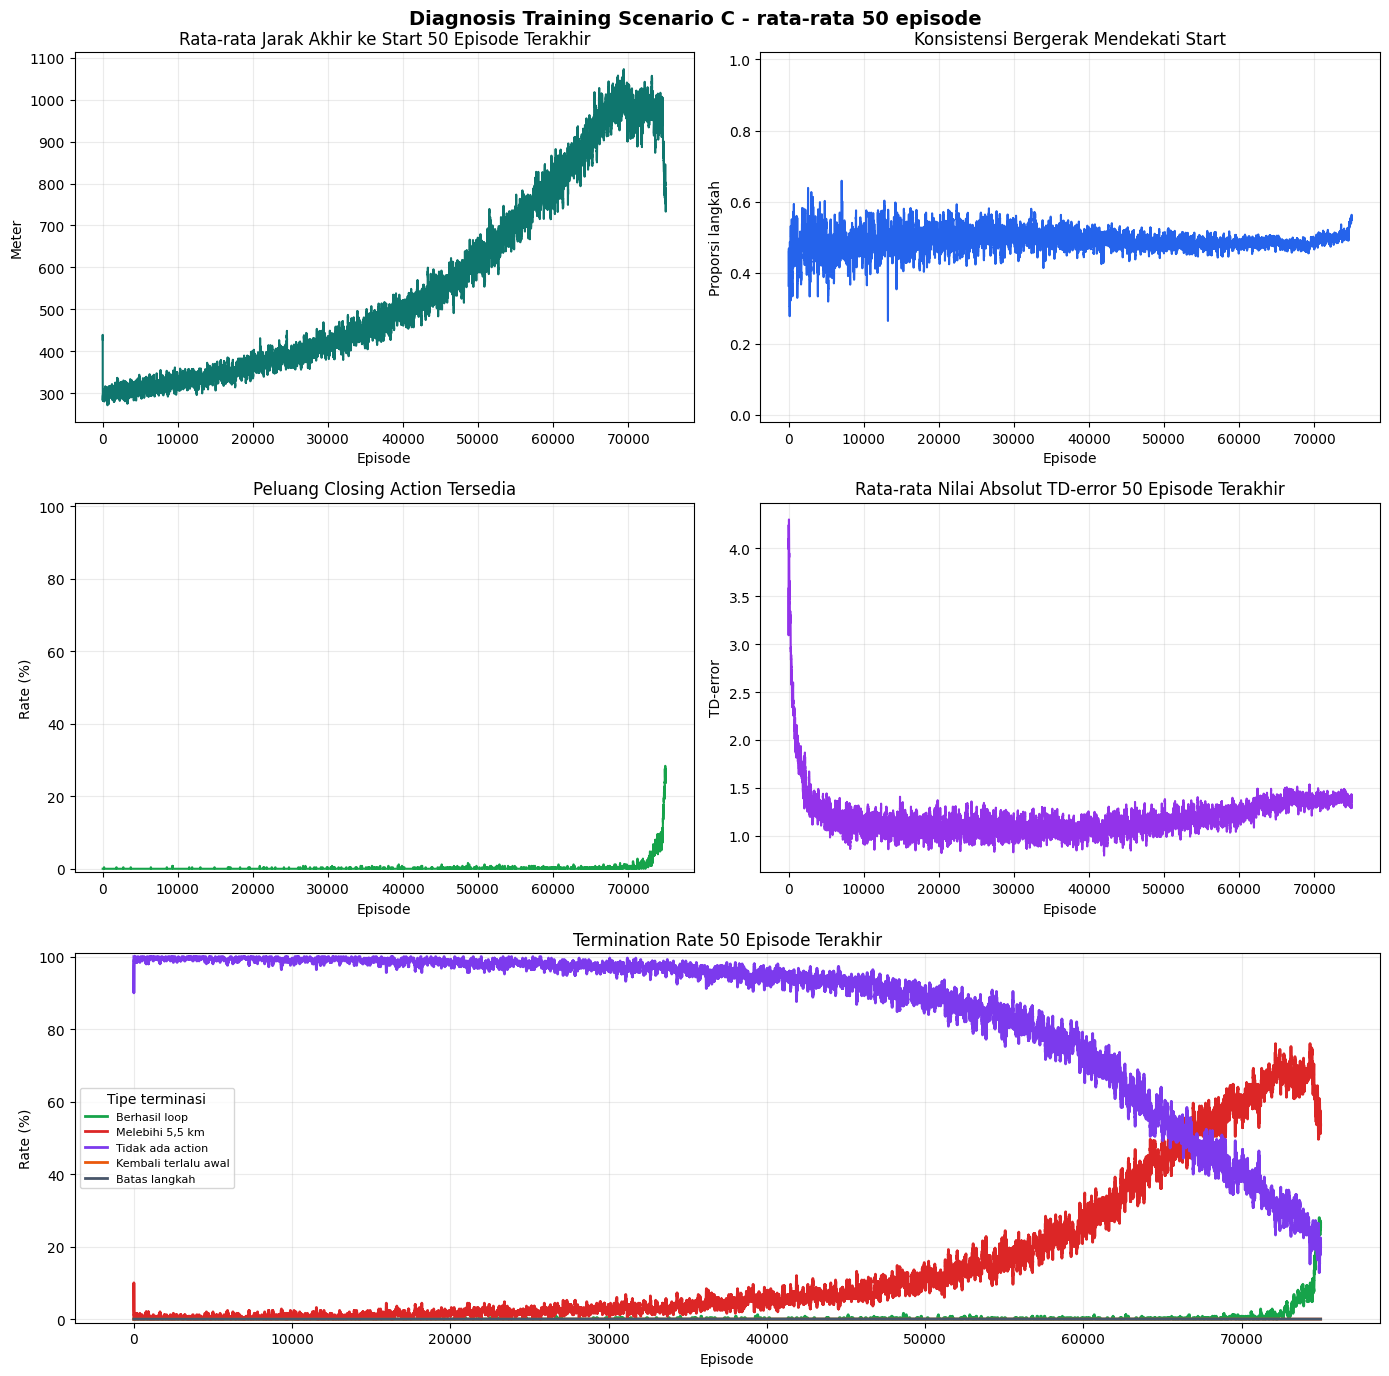

=== Q-TABLE / SEED YANG DIPILIH UNTUK PETA ===
Scenario: C; seed: 2
Metrik: is_loop=True, jarak=4978.81 m, galat=21.19 m, comfort=0.706, return_progress=0.821, jarak akhir ke start=0.00 m, terminasi=success
Alasan: Dipilih dari 3 loop valid: galat jarak paling kecil; jika setara, comfort lalu return progress lebih tinggi.


History: /Users/davidprastiyaimannuel/widya_kartika/david-31123022-tugas-akhir/hasil_bab_4/training_qlearning_5km/sensitivitas_episode_75000_C/training_history_C.csv
Evaluasi: /Users/davidprastiyaimannuel/widya_kartika/david-31123022-tugas-akhir/hasil_bab_4/training_qlearning_5km/sensitivitas_episode_75000_C/evaluation_metrics_C.csv
Diagnosis: /Users/davidprastiyaimannuel/widya_kartika/david-31123022-tugas-akhir/hasil_bab_4/training_qlearning_5km/sensitivitas_episode_75000_C/diagnosis_metrics_C.csv
Termination rate training: /Users/davidprastiyaimannuel/widya_kartika/david-31123022-tugas-akhir/hasil_bab_4/training_qlearning_5km/sensitivitas_episode_75000_C/termination_rates_training_C.csv
Termination rate evaluasi: /Users/davidprastiyaimannuel/widya_kartika/david-31123022-tugas-akhir/hasil_bab_4/training_qlearning_5km/sensitivitas_episode_75000_C/termination_rates_evaluation_C.csv
Grafik training utama: /Users/davidprastiyaimannuel/widya_kartika/david-31123022-tugas-akhir/hasil_bab_4/t

In [65]:
import importlib
# Memuat ulang core agar notebook memakai fungsi dan parameter terbaru.
importlib.reload(rute_lari_core)

result_c_75000 = rute_lari_core.run_scenario_experiment(
    G, START_NODE, 'C',
    episodes=75_000,
    result_subdir='sensitivitas_episode_75000_C',
)


### 2.5 Ringkasan epsilon decay dinamis

Tabel dan grafik menggunakan evaluasi greedy lima seed pada setiap jumlah episode. Bandingkan terutama keberhasilan loop, galat jarak, konsistensi bergerak mendekati start, dan peluang closing action tersedia.


,episodes,epsilon_decay_episodes,success_rate_greedy,mean_distance_error_m,mean_total_reward,mean_comfort,mean_return_progress_ratio,closing_action_available_rate
0,30000,None,0.2,409.429003,-28.053807,0.694525,0.604156,0.2
1,40000,None,0.4,354.492438,5.938448,0.702006,0.656973,0.4
2,50000,None,0.4,422.306708,4.001773,0.704572,0.615112,0.4
3,75000,None,0.6,339.394803,21.622152,0.724066,0.635878,0.6


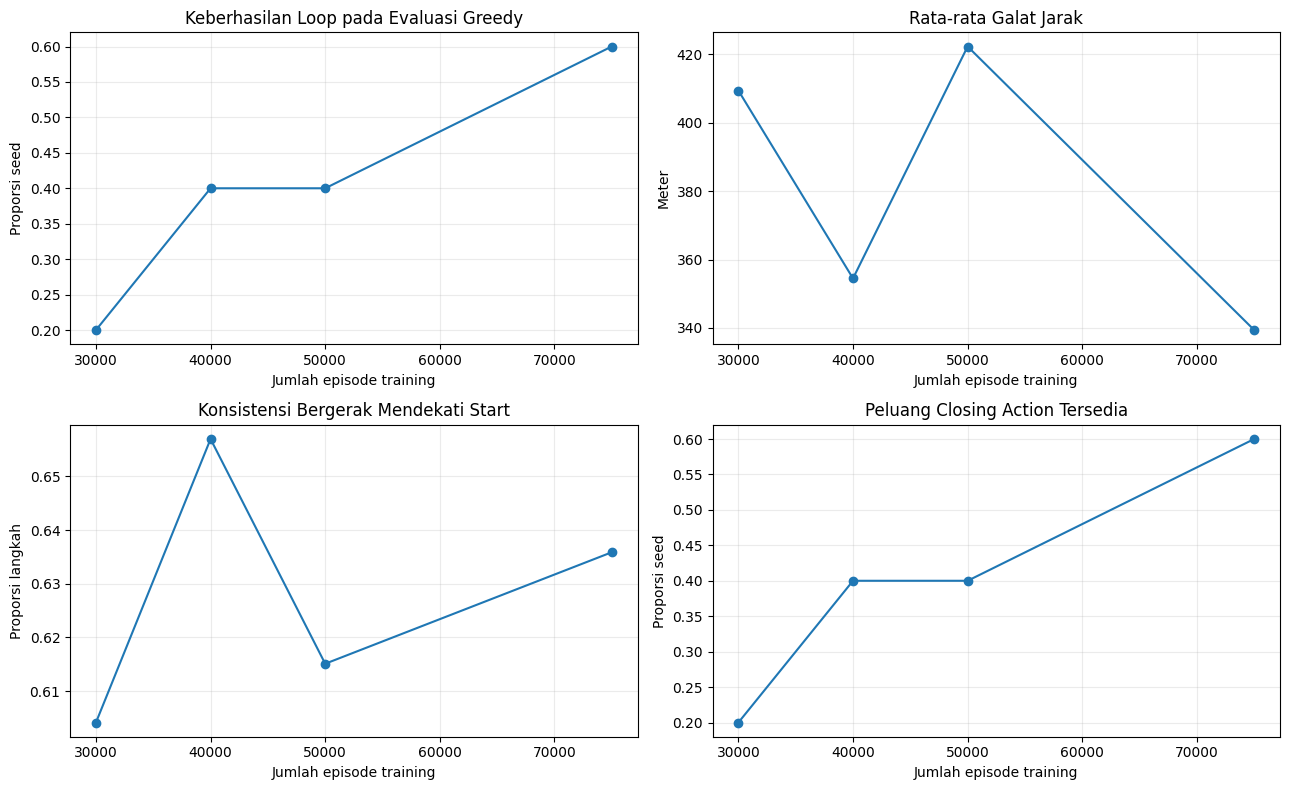

In [66]:
import matplotlib.pyplot as plt
import pandas as pd

# Epsilon turun sepanjang total episode masing-masing percobaan.
# Ringkasan ini adalah eksperimen pendahuluan, bukan dasar perbandingan final.
dynamic_decay_results = {
    30_000: result_c_30000,
    40_000: result_c_40000,
    50_000: result_c_50000,
    75_000: result_c_75000,
}

summary_rows = []
for episodes, result in dynamic_decay_results.items():
    metrics = result['metrics']
    summary_rows.append({
        'episodes': episodes,
        'epsilon_decay_episodes': result['epsilon_decay_episodes'],
        'success_rate_greedy': metrics['is_loop'].mean(),
        'mean_distance_error_m': metrics['absolute_distance_error_m'].mean(),
        'mean_total_reward': metrics['total_reward'].mean(),
        'mean_comfort': metrics['mean_comfort'].mean(),
        'mean_return_progress_ratio': metrics['return_progress_ratio'].mean(),
        'closing_action_available_rate': metrics['closing_action_available'].mean(),
    })

dynamic_decay_sensitivity_df = pd.DataFrame(summary_rows).sort_values('episodes')
display(dynamic_decay_sensitivity_df)

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
plots = [
    ('success_rate_greedy', 'Keberhasilan Loop pada Evaluasi Greedy', 'Proporsi seed'),
    ('mean_distance_error_m', 'Rata-rata Galat Jarak', 'Meter'),
    ('mean_return_progress_ratio', 'Konsistensi Bergerak Mendekati Start', 'Proporsi langkah'),
    ('closing_action_available_rate', 'Peluang Closing Action Tersedia', 'Proporsi seed'),
]
for axis, (column, title, ylabel) in zip(axes.flat, plots):
    axis.plot(dynamic_decay_sensitivity_df['episodes'], dynamic_decay_sensitivity_df[column], marker='o')
    axis.set(title=title, xlabel='Jumlah episode training', ylabel=ylabel)
    axis.grid(alpha=0.25)
plt.tight_layout()
plt.show()


## 3. Eksperimen utama: epsilon decay tetap 50.000 episode

Bagian ini menguji Scenario C pada 50.000, 75.000, 100.000, dan 150.000 episode. Epsilon turun dari 1,00 ke 0,05 hanya selama 50.000 episode pertama, lalu tetap 0,05 sampai training selesai. Dengan demikian, tambahan durasi setelah 50k dapat dibaca sebagai fase perbaikan kebijakan pada tingkat eksplorasi minimum yang sama.

Setiap titik melatih ulang lima seed dari awal. Training 50k dijalankan ulang agar kelompok ini mandiri, walaupun jadwal epsilon-nya secara matematis sama dengan eksperimen dinamis 50k. Total beban kelompok ini adalah 5 seed × (50.000 + 75.000 + 100.000 + 150.000) = 1.875.000 episode.


### 3.1 Training 50.000 episode dengan epsilon decay 50.000


Menjalankan Scenario C: 5 seed x 50,000 episode
Jadwal epsilon: turun selama 50,000 episode, lalu tetap 0.05
seed=0: success, 5.33 km, is_loop=True
seed=1: over_distance, 5.56 km, is_loop=False
seed=2: over_distance, 5.52 km, is_loop=False
seed=3: success, 4.82 km, is_loop=True
seed=4: over_distance, 5.52 km, is_loop=False
Tampilan vertikal metrik evaluasi utama per seed


seed,0,1,2,3,4
is_loop,True,False,False,True,False
total_distance_m,5325.293749,5563.763006,5522.265793,4817.120312,5517.331307
absolute_distance_error_m,325.293749,563.763006,522.265793,182.879688,517.331307
total_reward,94.972197,-40.888742,-73.045352,94.495602,-55.52484
mean_comfort,0.7037,0.714527,0.680621,0.70488,0.719132
return_progress_ratio,0.857143,0.355556,0.581395,0.868421,0.413043
distance_to_start_at_end_m,0.0,1344.104659,1368.309026,0.0,1041.37972
closing_action_available,True,False,False,True,False
termination_reason,success,over_distance,over_distance,success,over_distance


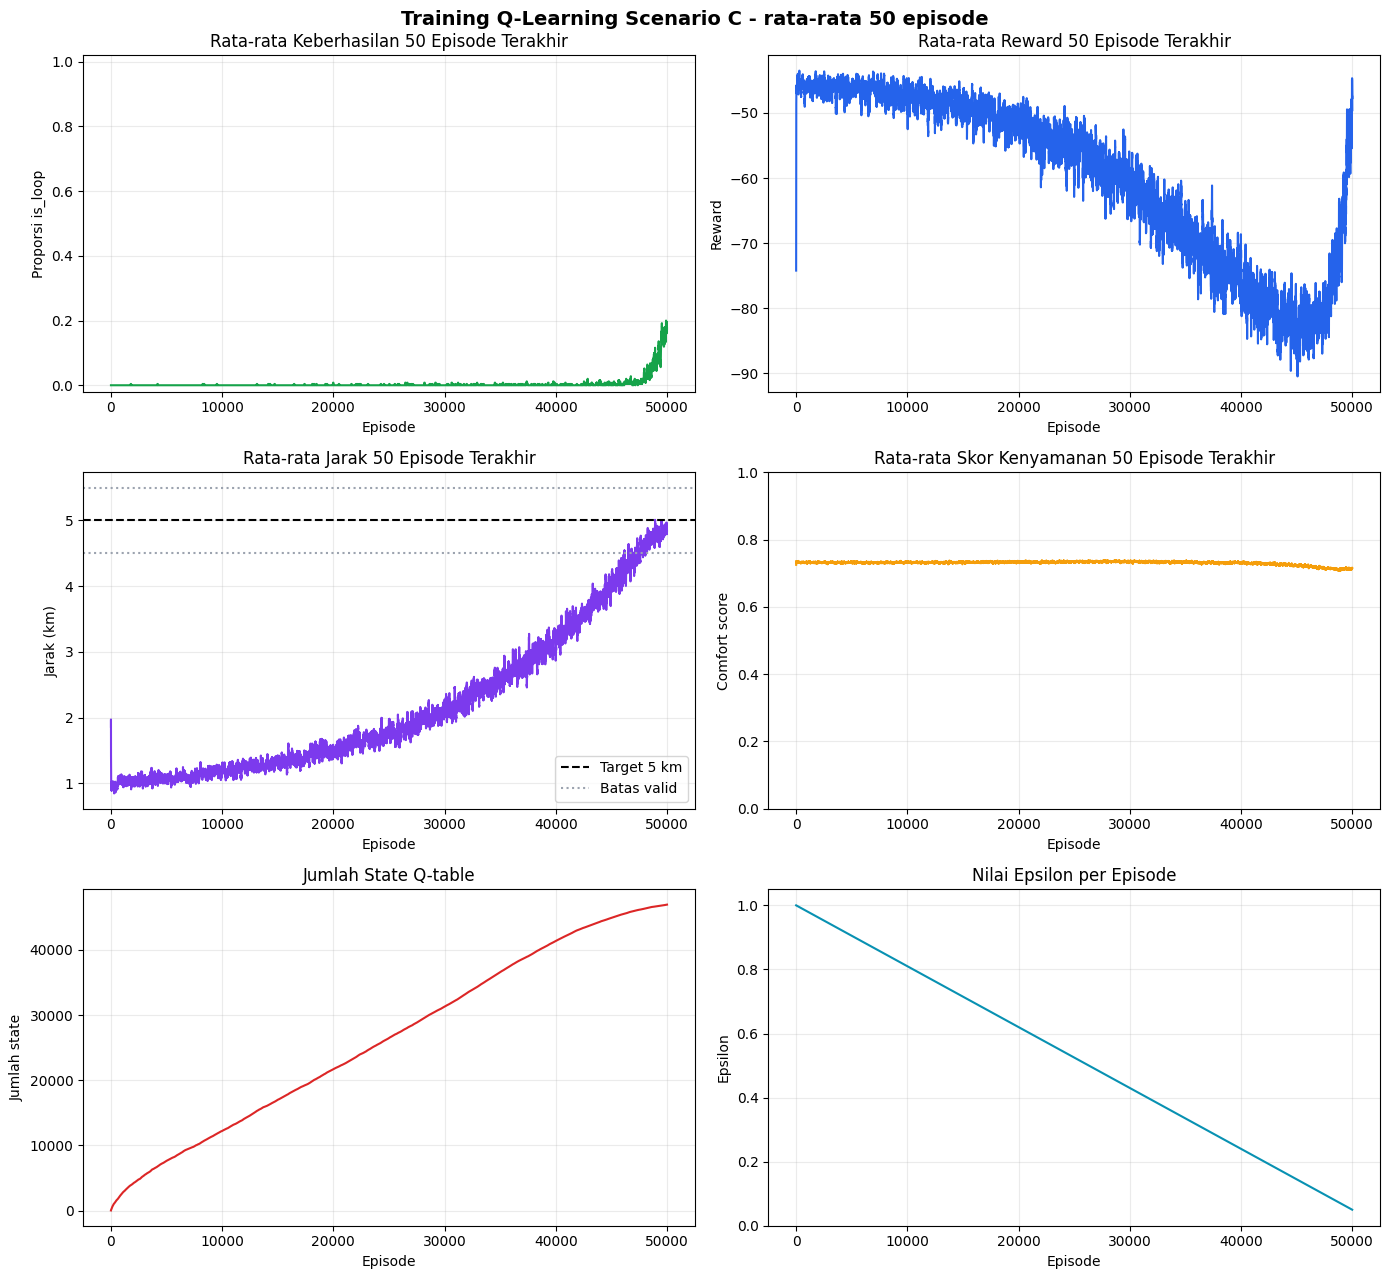

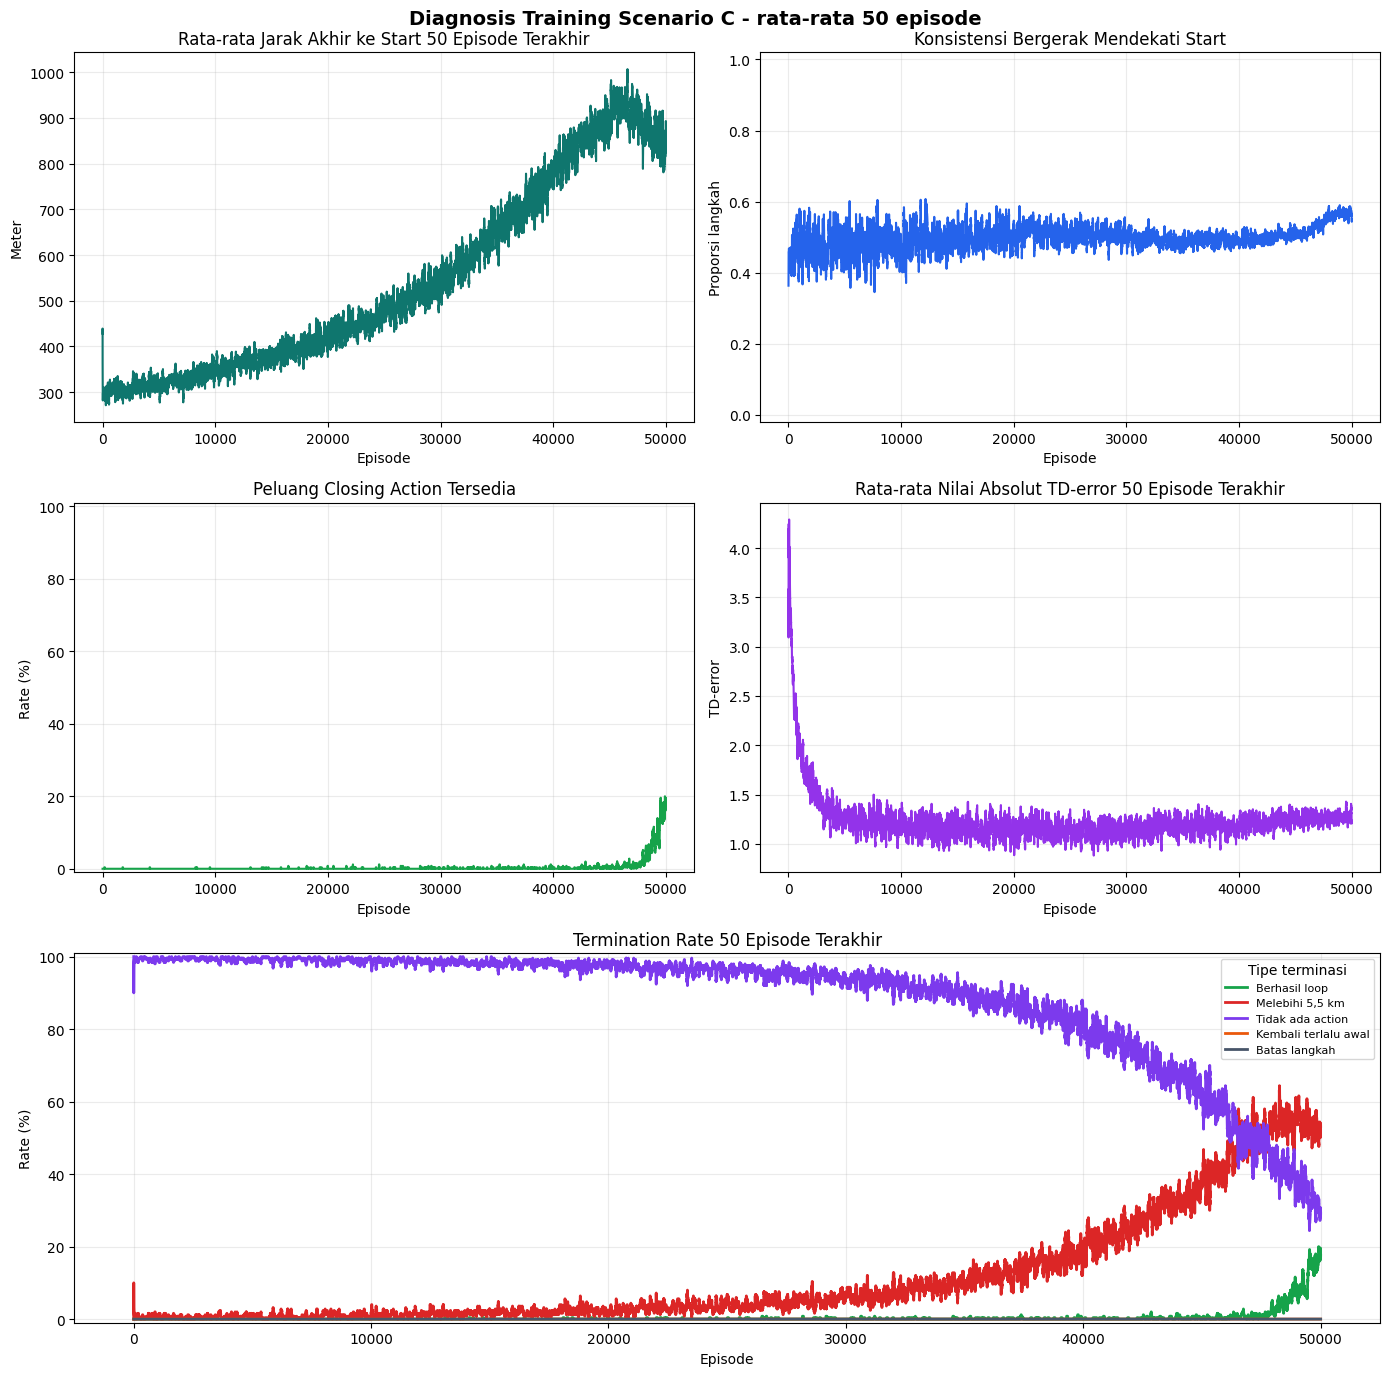

=== Q-TABLE / SEED YANG DIPILIH UNTUK PETA ===
Scenario: C; seed: 3
Metrik: is_loop=True, jarak=4817.12 m, galat=182.88 m, comfort=0.705, return_progress=0.868, jarak akhir ke start=0.00 m, terminasi=success
Alasan: Dipilih dari 2 loop valid: galat jarak paling kecil; jika setara, comfort lalu return progress lebih tinggi.


History: /Users/davidprastiyaimannuel/widya_kartika/david-31123022-tugas-akhir/hasil_bab_4/training_qlearning_5km/sensitivitas_epsilon_tetap_50000_episode_50000_C/training_history_C.csv
Evaluasi: /Users/davidprastiyaimannuel/widya_kartika/david-31123022-tugas-akhir/hasil_bab_4/training_qlearning_5km/sensitivitas_epsilon_tetap_50000_episode_50000_C/evaluation_metrics_C.csv
Diagnosis: /Users/davidprastiyaimannuel/widya_kartika/david-31123022-tugas-akhir/hasil_bab_4/training_qlearning_5km/sensitivitas_epsilon_tetap_50000_episode_50000_C/diagnosis_metrics_C.csv
Termination rate training: /Users/davidprastiyaimannuel/widya_kartika/david-31123022-tugas-akhir/hasil_bab_4/training_qlearning_5km/sensitivitas_epsilon_tetap_50000_episode_50000_C/termination_rates_training_C.csv
Termination rate evaluasi: /Users/davidprastiyaimannuel/widya_kartika/david-31123022-tugas-akhir/hasil_bab_4/training_qlearning_5km/sensitivitas_epsilon_tetap_50000_episode_50000_C/termination_rates_evaluation_C.csv
Grafik

In [67]:
import importlib
# Memuat ulang core agar notebook memakai fungsi dan parameter terbaru.
importlib.reload(rute_lari_core)

result_c_fixed_50000 = rute_lari_core.run_scenario_experiment(
    G, START_NODE, 'C',
    episodes=50_000,
    # Epsilon turun hanya pada 50.000 episode pertama, kemudian tetap 0,05.
    epsilon_decay_episodes=50_000,
    result_subdir='sensitivitas_epsilon_tetap_50000_episode_50000_C',
)


### 3.2 Training 75.000 episode dengan epsilon decay 50.000


Menjalankan Scenario C: 5 seed x 75,000 episode
Jadwal epsilon: turun selama 50,000 episode, lalu tetap 0.05
seed=0: success, 5.05 km, is_loop=True
seed=1: success, 4.78 km, is_loop=True
seed=2: success, 4.82 km, is_loop=True
seed=3: success, 4.82 km, is_loop=True
seed=4: success, 4.52 km, is_loop=True
Tampilan vertikal metrik evaluasi utama per seed


seed,0,1,2,3,4
is_loop,True,True,True,True,True
total_distance_m,5046.080412,4781.432387,4823.664255,4822.786549,4517.329762
absolute_distance_error_m,46.080412,218.567613,176.335745,177.213451,482.670238
total_reward,93.655811,76.20473,93.127034,93.094838,74.347058
mean_comfort,0.701197,0.706965,0.699512,0.698881,0.702802
return_progress_ratio,0.828571,0.769231,0.848485,0.861111,0.703704
distance_to_start_at_end_m,0.0,0.0,0.0,0.0,0.0
closing_action_available,True,True,True,True,True
termination_reason,success,success,success,success,success


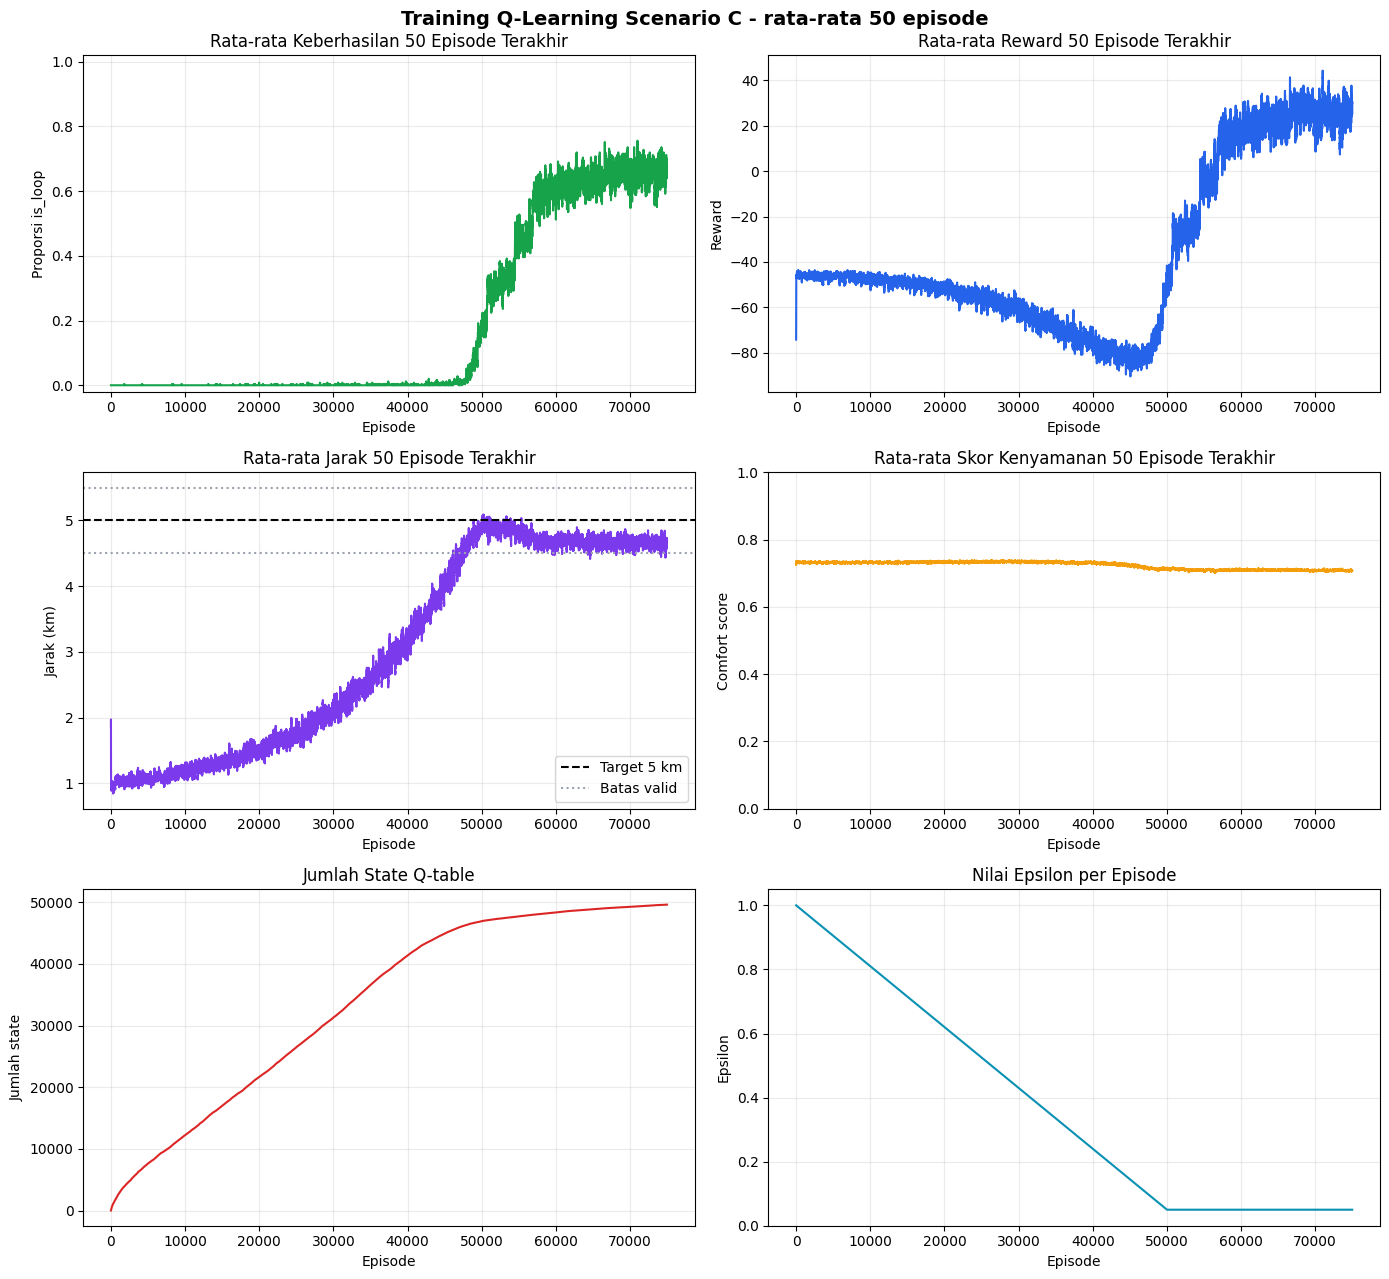

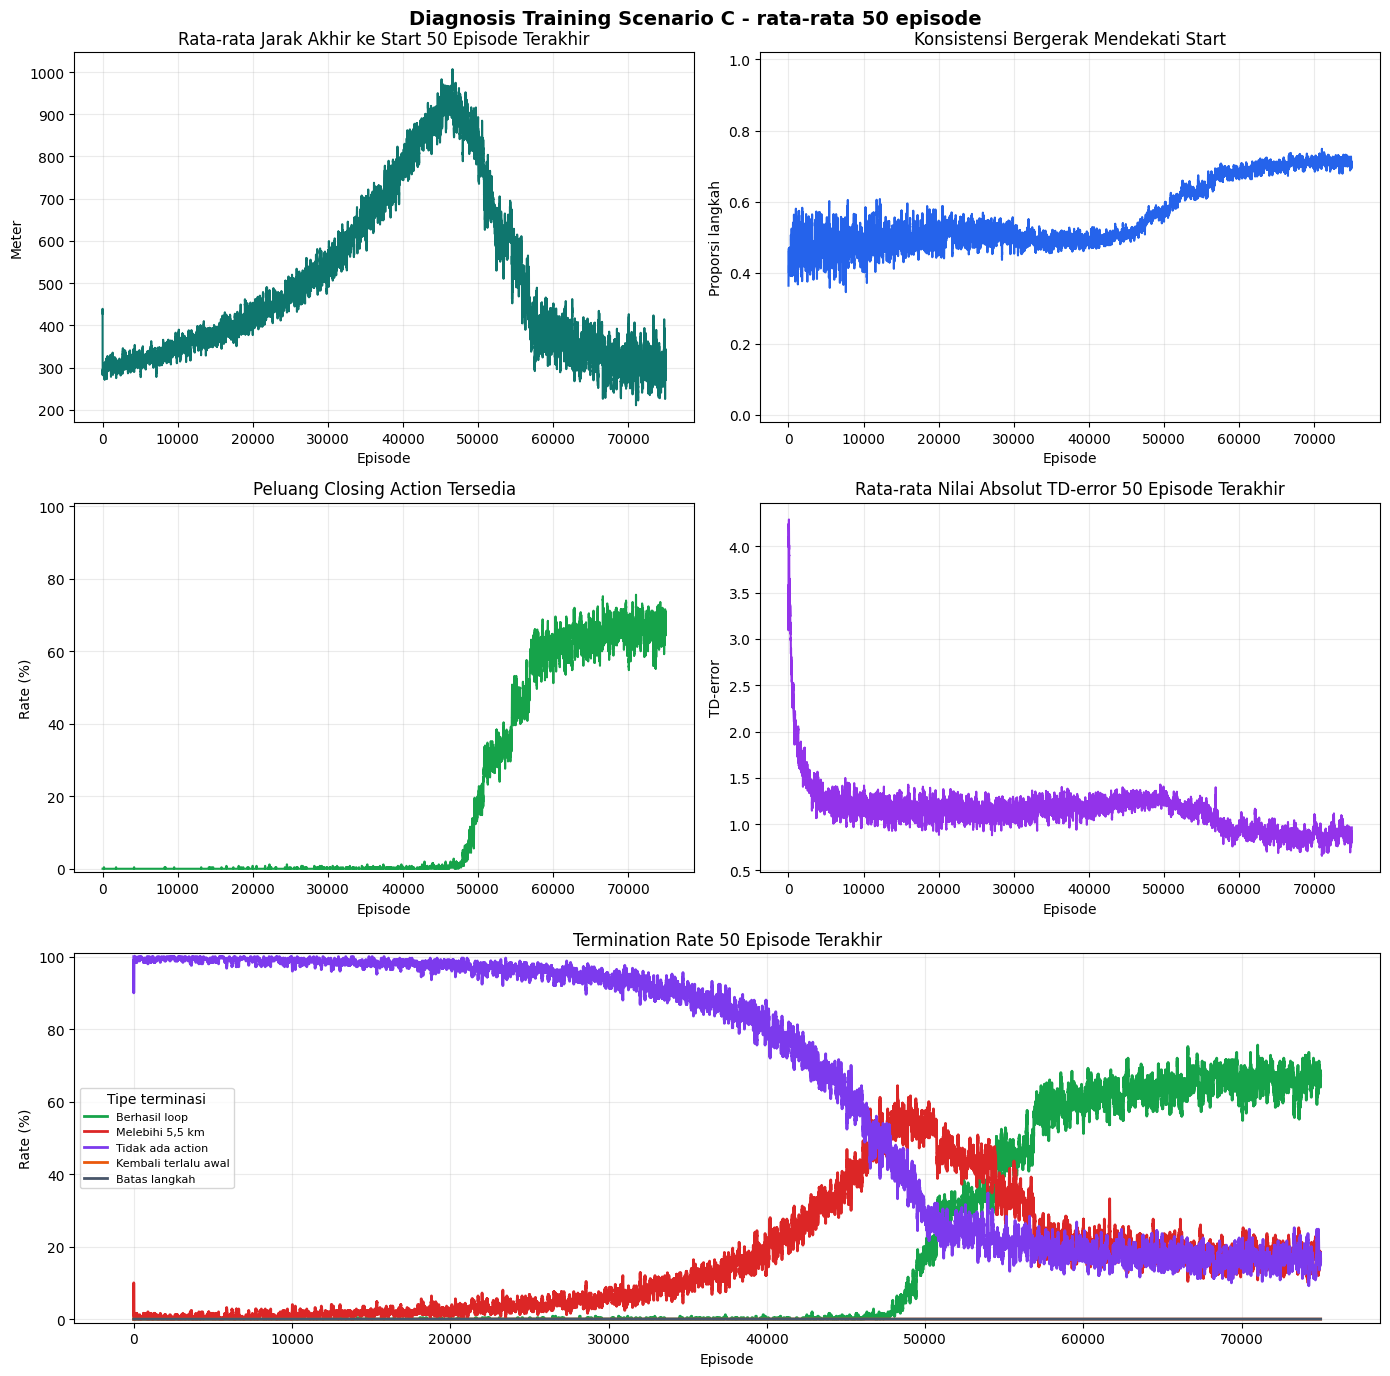

=== Q-TABLE / SEED YANG DIPILIH UNTUK PETA ===
Scenario: C; seed: 0
Metrik: is_loop=True, jarak=5046.08 m, galat=46.08 m, comfort=0.701, return_progress=0.829, jarak akhir ke start=0.00 m, terminasi=success
Alasan: Dipilih dari 5 loop valid: galat jarak paling kecil; jika setara, comfort lalu return progress lebih tinggi.


History: /Users/davidprastiyaimannuel/widya_kartika/david-31123022-tugas-akhir/hasil_bab_4/training_qlearning_5km/sensitivitas_epsilon_tetap_50000_episode_75000_C/training_history_C.csv
Evaluasi: /Users/davidprastiyaimannuel/widya_kartika/david-31123022-tugas-akhir/hasil_bab_4/training_qlearning_5km/sensitivitas_epsilon_tetap_50000_episode_75000_C/evaluation_metrics_C.csv
Diagnosis: /Users/davidprastiyaimannuel/widya_kartika/david-31123022-tugas-akhir/hasil_bab_4/training_qlearning_5km/sensitivitas_epsilon_tetap_50000_episode_75000_C/diagnosis_metrics_C.csv
Termination rate training: /Users/davidprastiyaimannuel/widya_kartika/david-31123022-tugas-akhir/hasil_bab_4/training_qlearning_5km/sensitivitas_epsilon_tetap_50000_episode_75000_C/termination_rates_training_C.csv
Termination rate evaluasi: /Users/davidprastiyaimannuel/widya_kartika/david-31123022-tugas-akhir/hasil_bab_4/training_qlearning_5km/sensitivitas_epsilon_tetap_50000_episode_75000_C/termination_rates_evaluation_C.csv
Grafik

In [68]:
import importlib
# Memuat ulang core agar notebook memakai fungsi dan parameter terbaru.
importlib.reload(rute_lari_core)

result_c_fixed_75000 = rute_lari_core.run_scenario_experiment(
    G, START_NODE, 'C',
    episodes=75_000,
    # Epsilon turun hanya pada 50.000 episode pertama, kemudian tetap 0,05.
    epsilon_decay_episodes=50_000,
    result_subdir='sensitivitas_epsilon_tetap_50000_episode_75000_C',
)


### 3.3 Training 100.000 episode dengan epsilon decay 50.000


Menjalankan Scenario C: 5 seed x 100,000 episode
Jadwal epsilon: turun selama 50,000 episode, lalu tetap 0.05
seed=0: success, 5.04 km, is_loop=True
seed=1: success, 4.51 km, is_loop=True
seed=2: success, 4.84 km, is_loop=True
seed=3: success, 4.82 km, is_loop=True
seed=4: success, 4.54 km, is_loop=True
Tampilan vertikal metrik evaluasi utama per seed


seed,0,1,2,3,4
is_loop,True,True,True,True,True
total_distance_m,5039.444003,4505.214771,4836.700628,4822.786549,4538.181404
absolute_distance_error_m,39.444003,494.785229,163.299372,177.213451,461.818596
total_reward,93.68024,82.203744,93.225139,93.094838,73.205197
mean_comfort,0.701947,0.70247,0.701003,0.698881,0.691597
return_progress_ratio,0.828571,0.76,0.848485,0.861111,0.62963
distance_to_start_at_end_m,0.0,0.0,0.0,0.0,0.0
closing_action_available,True,True,True,True,True
termination_reason,success,success,success,success,success


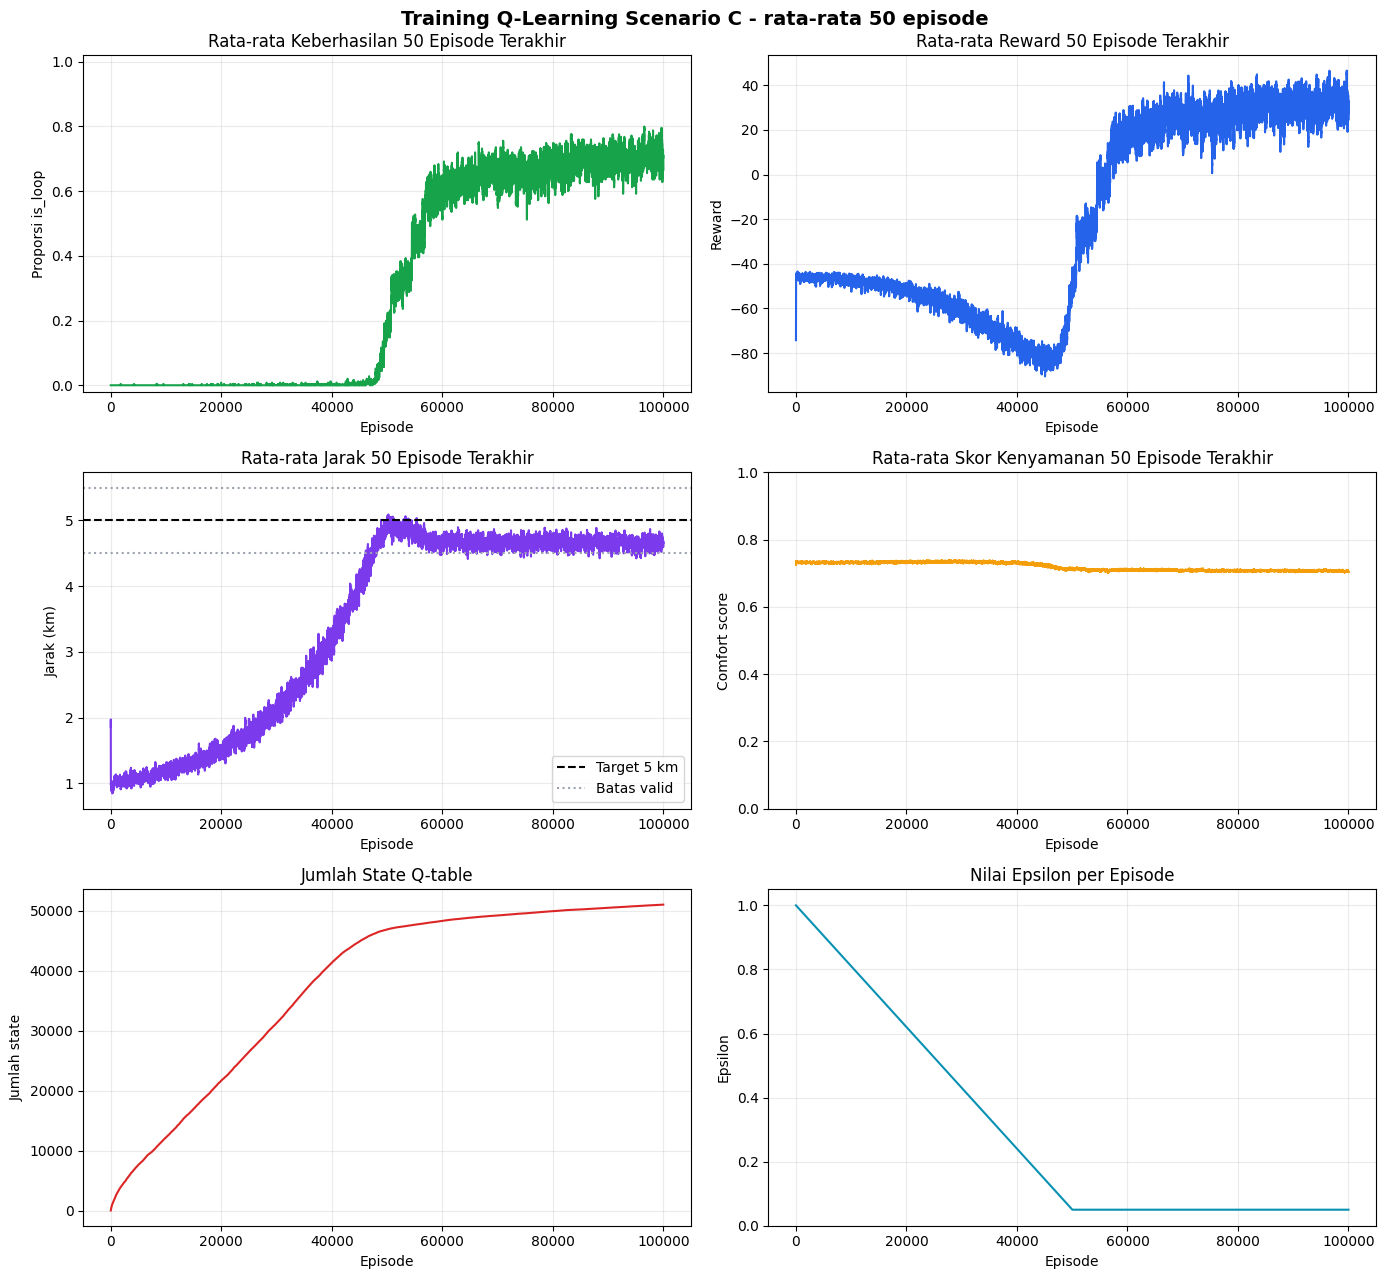

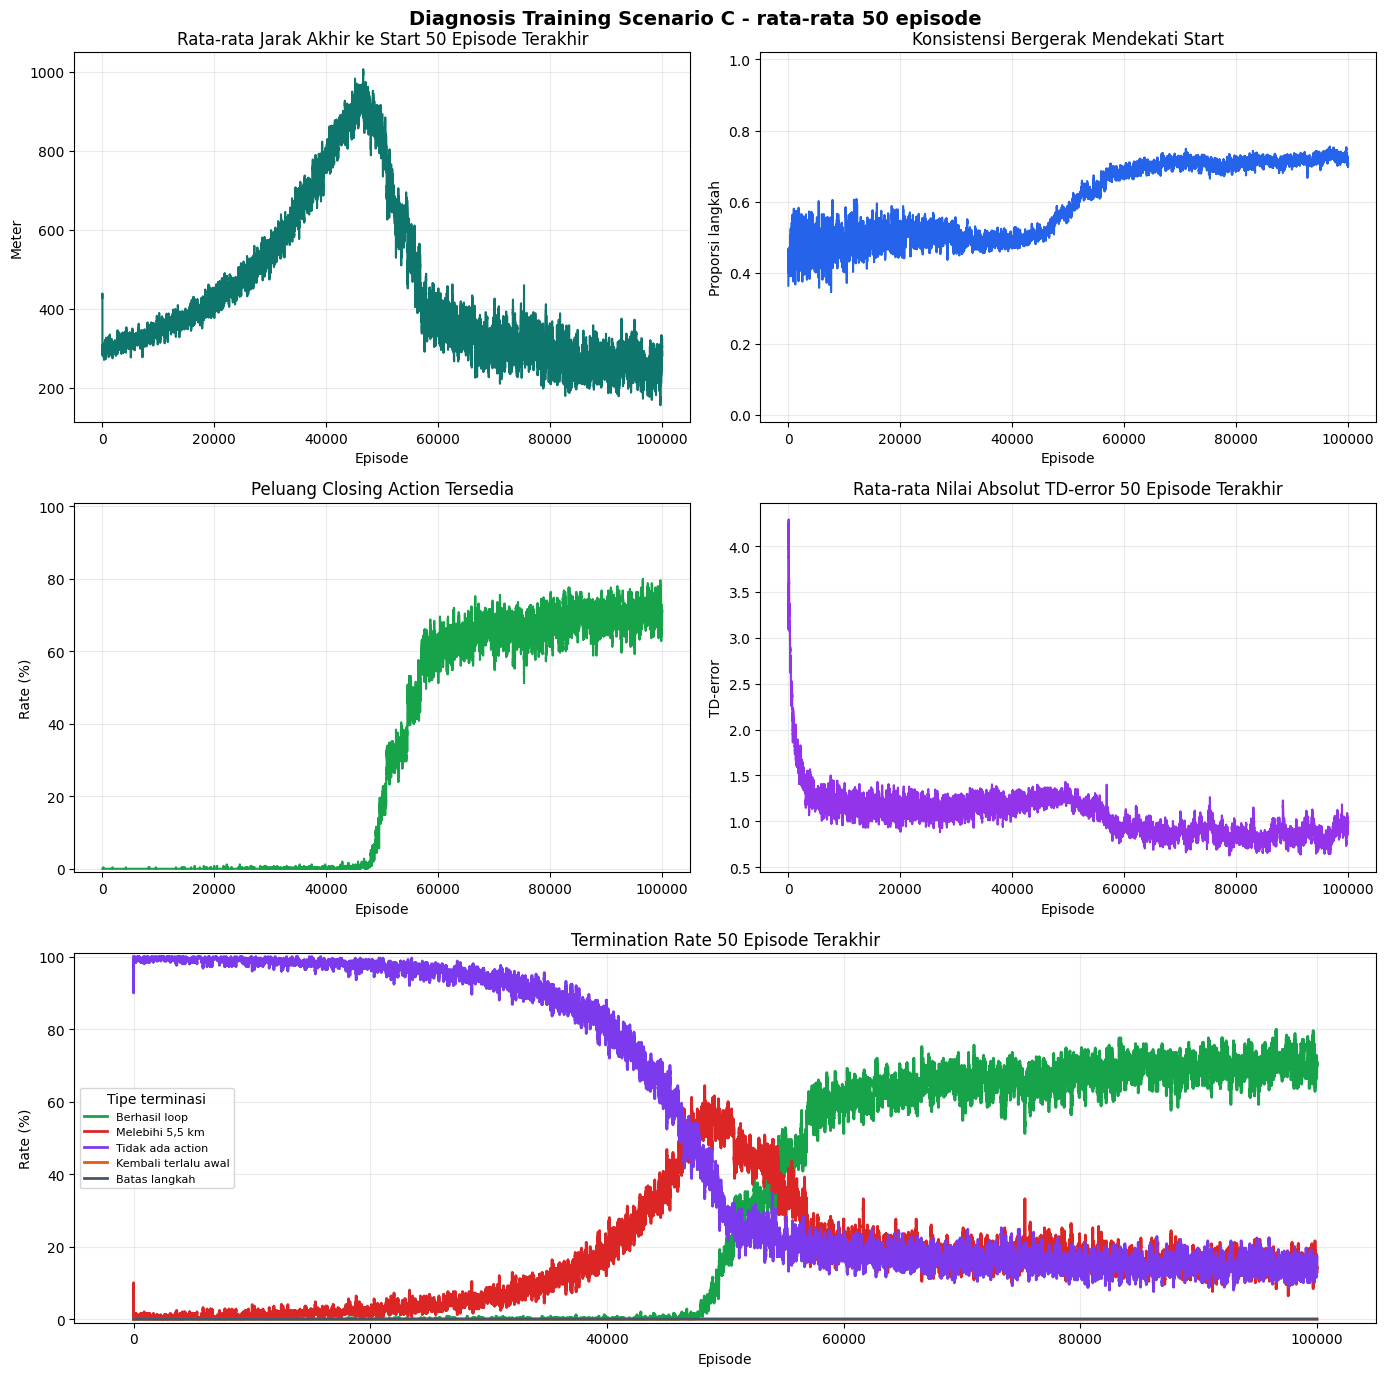

=== Q-TABLE / SEED YANG DIPILIH UNTUK PETA ===
Scenario: C; seed: 0
Metrik: is_loop=True, jarak=5039.44 m, galat=39.44 m, comfort=0.702, return_progress=0.829, jarak akhir ke start=0.00 m, terminasi=success
Alasan: Dipilih dari 5 loop valid: galat jarak paling kecil; jika setara, comfort lalu return progress lebih tinggi.


History: /Users/davidprastiyaimannuel/widya_kartika/david-31123022-tugas-akhir/hasil_bab_4/training_qlearning_5km/sensitivitas_epsilon_tetap_50000_episode_100000_C/training_history_C.csv
Evaluasi: /Users/davidprastiyaimannuel/widya_kartika/david-31123022-tugas-akhir/hasil_bab_4/training_qlearning_5km/sensitivitas_epsilon_tetap_50000_episode_100000_C/evaluation_metrics_C.csv
Diagnosis: /Users/davidprastiyaimannuel/widya_kartika/david-31123022-tugas-akhir/hasil_bab_4/training_qlearning_5km/sensitivitas_epsilon_tetap_50000_episode_100000_C/diagnosis_metrics_C.csv
Termination rate training: /Users/davidprastiyaimannuel/widya_kartika/david-31123022-tugas-akhir/hasil_bab_4/training_qlearning_5km/sensitivitas_epsilon_tetap_50000_episode_100000_C/termination_rates_training_C.csv
Termination rate evaluasi: /Users/davidprastiyaimannuel/widya_kartika/david-31123022-tugas-akhir/hasil_bab_4/training_qlearning_5km/sensitivitas_epsilon_tetap_50000_episode_100000_C/termination_rates_evaluation_C.csv
G

In [69]:
import importlib
# Memuat ulang core agar notebook memakai fungsi dan parameter terbaru.
importlib.reload(rute_lari_core)

result_c_fixed_100000 = rute_lari_core.run_scenario_experiment(
    G, START_NODE, 'C',
    episodes=100_000,
    # Epsilon turun hanya pada 50.000 episode pertama, kemudian tetap 0,05.
    epsilon_decay_episodes=50_000,
    result_subdir='sensitivitas_epsilon_tetap_50000_episode_100000_C',
)


### 3.4 Training 150.000 episode dengan epsilon decay 50.000


In [ ]:
import importlib
# Memuat ulang core agar notebook memakai fungsi dan parameter terbaru.
importlib.reload(rute_lari_core)

result_c_fixed_150000 = rute_lari_core.run_scenario_experiment(
    G, START_NODE, 'C',
    episodes=150_000,
    # Epsilon turun hanya pada 50.000 episode pertama, kemudian tetap 0,05.
    epsilon_decay_episodes=50_000,
    result_subdir='sensitivitas_epsilon_tetap_50000_episode_150000_C',
)


Menjalankan Scenario C: 5 seed x 150,000 episode
Jadwal epsilon: turun selama 50,000 episode, lalu tetap 0.05


### 3.5 Ringkasan epsilon decay tetap

Tabel dan grafik menggunakan evaluasi greedy lima seed. Karena seluruh titik memakai horizon decay 50.000 episode yang sama, perbedaan hasil terutama mencerminkan tambahan durasi training. TD-error dibaca dari grafik diagnosis pada masing-masing training.


,episodes,epsilon_decay_episodes,success_rate_greedy,mean_distance_error_m,mean_total_reward,mean_comfort,mean_return_progress_ratio,closing_action_available_rate
0,50000,50000,0.4,422.306708,4.001773,0.704572,0.615112,0.4
1,75000,50000,1.0,220.173492,86.085894,0.701872,0.802220,1.0
2,100000,50000,1.0,267.312130,87.081832,0.699180,0.785559,1.0
3,150000,50000,0.8,315.615134,45.049437,0.704532,0.734583,0.8


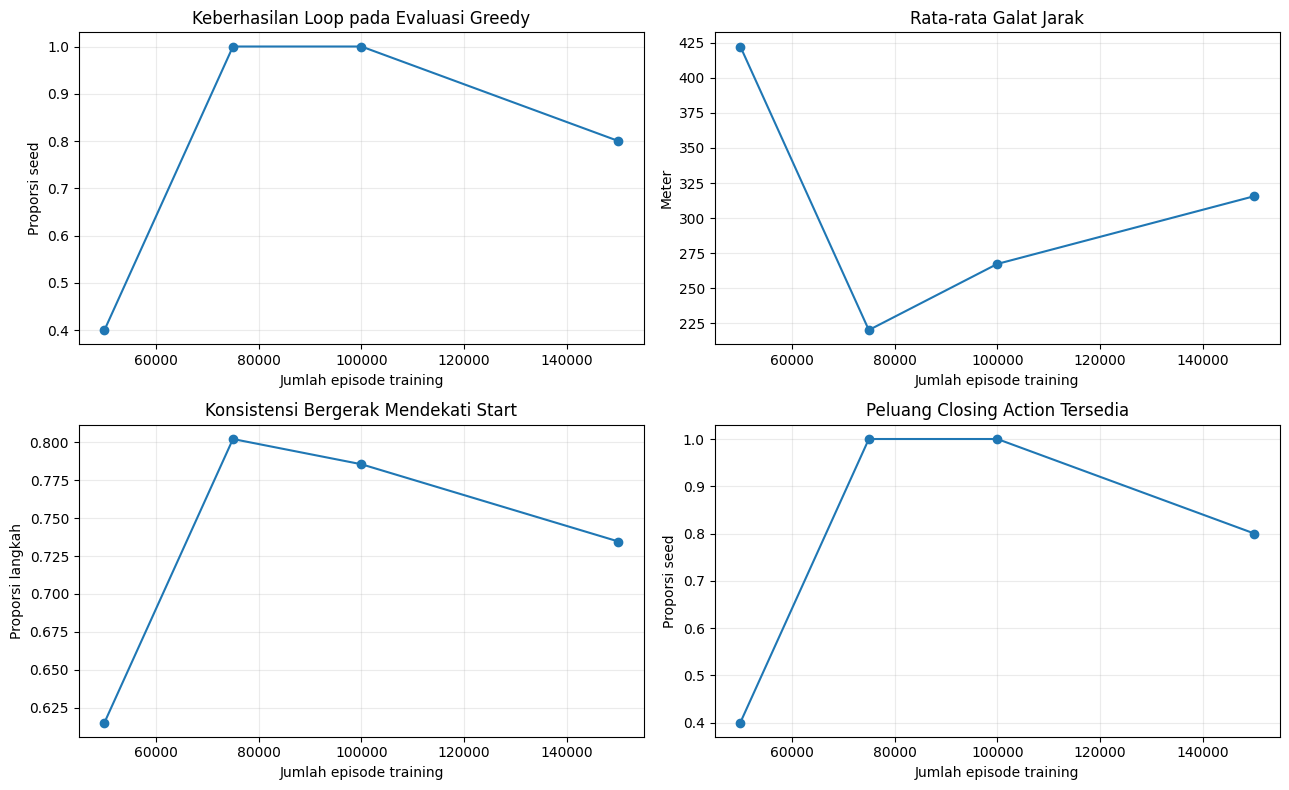

In [71]:
import matplotlib.pyplot as plt
import pandas as pd

# Semua hasil memakai epsilon yang turun selama 50.000 episode pertama, lalu tetap 0,05.
# Perbedaan antar titik terutama berasal dari tambahan durasi training.
fixed_decay_results = {
    50_000: result_c_fixed_50000,
    75_000: result_c_fixed_75000,
    100_000: result_c_fixed_100000,
    150_000: result_c_fixed_150000,
}

summary_rows = []
for episodes, result in fixed_decay_results.items():
    metrics = result['metrics']
    summary_rows.append({
        'episodes': episodes,
        'epsilon_decay_episodes': result['epsilon_decay_episodes'],
        'success_rate_greedy': metrics['is_loop'].mean(),
        'mean_distance_error_m': metrics['absolute_distance_error_m'].mean(),
        'mean_total_reward': metrics['total_reward'].mean(),
        'mean_comfort': metrics['mean_comfort'].mean(),
        'mean_return_progress_ratio': metrics['return_progress_ratio'].mean(),
        'closing_action_available_rate': metrics['closing_action_available'].mean(),
    })

fixed_decay_sensitivity_df = pd.DataFrame(summary_rows).sort_values('episodes')
display(fixed_decay_sensitivity_df)

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
plots = [
    ('success_rate_greedy', 'Keberhasilan Loop pada Evaluasi Greedy', 'Proporsi seed'),
    ('mean_distance_error_m', 'Rata-rata Galat Jarak', 'Meter'),
    ('mean_return_progress_ratio', 'Konsistensi Bergerak Mendekati Start', 'Proporsi langkah'),
    ('closing_action_available_rate', 'Peluang Closing Action Tersedia', 'Proporsi seed'),
]
for axis, (column, title, ylabel) in zip(axes.flat, plots):
    axis.plot(fixed_decay_sensitivity_df['episodes'], fixed_decay_sensitivity_df[column], marker='o')
    axis.set(title=title, xlabel='Jumlah episode training', ylabel=ylabel)
    axis.grid(alpha=0.25)
plt.tight_layout()
plt.show()


## 4. Cara membaca hasil evaluasi

Tabel evaluasi utama memuat `is_loop`, `total_distance_m`, `absolute_distance_error_m`, `total_reward`, `mean_comfort`, `return_progress_ratio`, `distance_to_start_at_end_m`, `closing_action_available`, dan `termination_reason`.

Grafik diagnosis tetap membantu menjelaskan proses training, khususnya termination rate dan ketersediaan closing action.

Baca detail seluruh implementasi di `IMPLEMENTASI.md`.